# Ejercicio 1. Definición de skills propias para un agente de IA

Curso de Inteligencia Artificial y Minirobots. Capítulo 7, Inteligencia Artificial Generativa (José J. Martínez P.)

Ejercicio 7.11, numeral 1: *Con base en los skills en https://www.aihero.dev/ defina sus propias skills. En principio 4: 1. Un skill para documentar un ticket de trabajo, toda la descripción del trabajo por hacer. 2. Un skill de implementación, generación de código y pruebas. 3. Un skill de explicación, que genere un HTML que explique en detalle el trabajo realizado. 4. Un skill que lea y capture requerimientos de documentos provistos.*

El notebook hace tres cosas:

1. **Define** las cuatro skills, cada una como una carpeta con su `SKILL.md`, plantillas y scripts (secciones 4 a 7). Las celdas escriben los archivos en `skills/`.
2. **Verifica** que cumplan el formato de una skill y que sus descripciones distingan bien cuándo usar cada una (secciones 8 y 9).
3. **Las pone a trabajar** encadenadas sobre los **siete documentos de la clase**: de ellos salen los requerimientos del curso (ejercicios, reglas de selección y condiciones de entrega), que se cruzan con lo entregado en el repositorio; los pendientes del capítulo 7 pasan a tickets, los dos primeros del agente de mantenimiento (numeral 4) se implementan con sus pruebas y el resultado se explica en HTML (sección 10).

---

## 1. Planteamiento: qué es una skill

El capítulo define una skill como *"un paquete de folders de instrucciones, scripts y recursos, generalmente anclados por un archivo Markdown llamado SKILL.md"*. En la práctica es la forma de enseñarle a un agente (Claude Code, Codex, Cursor, Copilot y otros que adoptaron el formato abierto *Agent Skills*) **un procedimiento** que de otro modo habría que explicarle en cada conversación.

```
mi-skill/
├── SKILL.md          obligatorio: encabezado YAML (name, description) + instrucciones
├── PLANTILLA.md      opcional: recursos que el agente lee cuando los necesita
├── scripts/          opcional: código que el agente ejecuta en lugar de razonar
└── assets/           opcional: archivos que se copian o usan en la salida
```

El agente no carga todo al tiempo. La carga es **progresiva**, en tres niveles:

| Nivel | Qué se carga | Cuándo | Consecuencia para el diseño |
|---|---|---|---|
| 1 | `name` y `description` del encabezado | Siempre, de todas las skills instaladas | La descripción decide si la skill se usa: debe decir **qué hace y cuándo usarla** |
| 2 | El cuerpo de `SKILL.md` | Cuando la descripción coincide con lo que pide el usuario | Instrucciones cortas y concretas; los detalles van en otros archivos |
| 3 | Plantillas, referencias y scripts | Solo si las instrucciones los mencionan y hacen falta | Los scripts se **ejecutan**, no se leen: su código no ocupa contexto |

De la tabla salen dos reglas que se aplican en todo el ejercicio: lo que necesita **criterio** (decidir si una frase es un requerimiento, redactar un criterio de aceptación) va como instrucción en `SKILL.md`; lo que es **mecánico** y debe salir igual siempre (extraer texto de un PDF, validar un ticket, correr una prueba, armar el HTML) va como script.

## 2. Las skills de referencia de AI Hero

AI Hero (Matt Pocock) publica un conjunto de skills de ingeniería de software organizadas como un flujo de trabajo (repositorio `mattpocock/skills`, licencia MIT). Las que sirven de base a este ejercicio son:

| Skill de AI Hero | Qué hace |
|---|---|
| `/grill-with-docs` | Entrevista exhaustiva al usuario para afinar un plan, y documenta glosario y decisiones |
| `/to-spec` | Convierte la conversación en una especificación: problema, solución, historias de usuario, decisiones y pruebas |
| `/to-tickets` | Parte la especificación en tickets como **rebanadas verticales** (*tracer bullets*), cada uno con lo que lo bloquea y criterios de aceptación |
| `/implement` | Implementa un ticket usando `/tdd`, corre las pruebas y hace *commit* |
| `/tdd` | Referencia del ciclo rojo → verde: probar en las **costuras** acordadas, comportamiento por la interfaz pública, sin pruebas tautológicas |
| `/code-review` | Revisión del trabajo terminado |
| `/teach` | Enseña un tema con **lecciones en HTML** autocontenidas, bonitas e imprimibles |

Las cuatro skills propias toman de ellas las ideas y las adaptan:

| Skill propia (numeral) | Se basa en | Qué se conserva | Qué cambia |
|---|---|---|---|
| `capturar-requerimientos` (4) | `/grill-with-docs`, `/to-spec` | Registrar lo ambiguo como pregunta en lugar de inventar | La fuente son **documentos**, no una entrevista; cada requerimiento lleva cita y página; script de extracción y detección |
| `documentar-ticket` (1) | `/to-tickets`, `/to-spec` | Rebanadas verticales, "bloqueado por", criterios de aceptación, nada de rutas ni código en el ticket | Plantilla completa (alcance, fuera de alcance, riesgos, estimación, definición de terminado), criterios *Dado/Cuando/Entonces* con identificador, **validador** automático |
| `implementar-con-pruebas` (2) | `/implement`, `/tdd`, `/code-review` | Costuras, rojo antes de verde, una rebanada a la vez, qué es una buena prueba | Script que ejecuta cada fase y deja **bitácora**; script de **trazabilidad** criterio → prueba; lista de revisión |
| `explicar-en-html` (3) | `/teach` | HTML autocontenido, legible e imprimible | Explica **trabajo terminado** con evidencia real (no enseña un tema); secciones obligatorias; generador con plantilla |

Las skills de AI Hero dependen de una configuración previa (`/setup-matt-pocock-skills`) que define el gestor de tickets del proyecto. Las propias no la necesitan: trabajan con archivos locales y, si existe un gestor como GitHub, lo indican como opción.

## 3. Diseño del conjunto

Las cuatro skills forman una cadena. La salida de cada una es la entrada de la siguiente, y los identificadores conectan todo, de modo que cualquier fila del HTML final se puede rastrear hasta una línea del documento original:

```
 documento ──► capturar-requerimientos ──► documentar-ticket ──► implementar-con-pruebas ──► explicar-en-html
 (.pdf .docx       requerimientos.md          tickets/NN-*.md        código + pruebas            explicacion.html
  .txt .md)        RF-01, RNF-01 ...          CA-01.1, CA-01.2 ...   bitácora TDD, pytest        tabla criterio → prueba
```

Convenciones comunes a las cuatro:

| Convención | Razón |
|---|---|
| Nombre en minúsculas con guiones, en español, verbo + objeto | Es el formato exigido para `name` y deja claro qué hace |
| Descripción = qué hace + "Úsala cuando ..." con las palabras que diría el usuario | Es lo único que el agente ve antes de decidir (nivel 1) |
| `SKILL.md` corto (menos de 100 líneas) con enlaces a plantillas y scripts | Carga progresiva: los detalles solo entran al contexto si hacen falta |
| Scripts en Python sin dependencias fuera de la biblioteca estándar (salvo `pypdf` y `python-docx` para leer esos formatos) | Corren en cualquier máquina donde corra el agente |
| Cada script termina con código 0 o 1 | El agente sabe si debe corregir algo sin interpretar el texto |

In [1]:
import ast
import html
import json
import py_compile
import re
import shutil
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import HTML, display

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

pd.set_option("display.max_colwidth", 120)

# En el repositorio el notebook vive en notebooks/; en Colab se trabaja en la carpeta actual
RAIZ = Path("..") if Path.cwd().name == "notebooks" else Path(".")
SK = RAIZ / "skills"            # aquí se escriben las cuatro skills
DEMO = RAIZ / "demo"            # aquí se ejecuta el caso de la sección 10
IMG = RAIZ / "img"              # figuras del documento
IMG.mkdir(exist_ok=True)

for carpeta in ["capturar-requerimientos/scripts", "documentar-ticket/scripts",
                "implementar-con-pruebas/scripts", "explicar-en-html/scripts", "explicar-en-html/assets"]:
    (SK / carpeta).mkdir(parents=True, exist_ok=True)
print("Skills en:", SK.resolve())

Skills en: /home/claude/7. IA Generativa/skills


La figura resume el flujo y la cadena de identificadores que lo atraviesa:

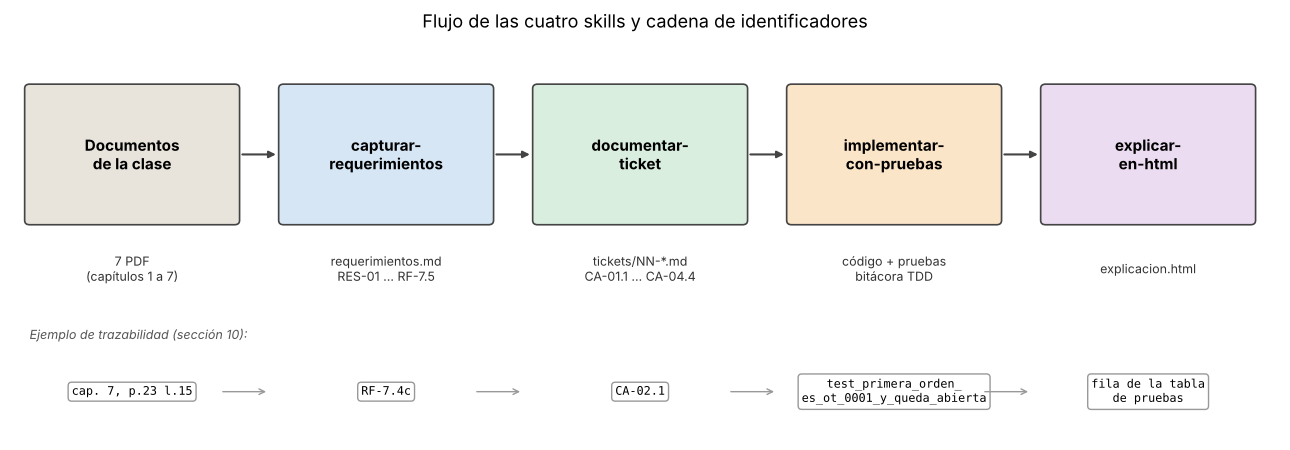

In [2]:
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.set_xlim(0, 13); ax.set_ylim(0, 4.6); ax.axis("off")
etapas = [("Documentos\nde la clase", "7 PDF\n(capítulos 1 a 7)", "#e8e4dc"),
          ("capturar-\nrequerimientos", "requerimientos.md\nRES-01 … RF-7.5", "#d6e6f5"),
          ("documentar-\nticket", "tickets/NN-*.md\nCA-01.1 … CA-04.4", "#d9eedf"),
          ("implementar-\ncon-pruebas", "código + pruebas\nbitácora TDD", "#fbe5c8"),
          ("explicar-\nen-html", "explicacion.html", "#ecdcf2")]
cadena = ["cap. 7, p.23 l.15", "RF-7.4c", "CA-02.1", "test_primera_orden_\nes_ot_0001_y_queda_abierta", "fila de la tabla\nde pruebas"]
for i, ((titulo, salida, color), enlace) in enumerate(zip(etapas, cadena)):
    x = 0.2 + i * 2.6
    ax.add_patch(FancyBboxPatch((x, 2.5), 2.1, 1.5, boxstyle="round,pad=0.05", fc=color, ec="#444", lw=1.2))
    ax.text(x + 1.05, 3.25, titulo, ha="center", va="center", fontsize=11, weight="bold")
    ax.text(x + 1.05, 1.95, salida, ha="center", va="center", fontsize=9, color="#333")
    ax.text(x + 1.05, 0.55, enlace, ha="center", va="center", fontsize=8.5, family="monospace",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#999"))
    if i < 4:
        ax.annotate("", xy=(x + 2.55, 3.25), xytext=(x + 2.15, 3.25), arrowprops=dict(arrowstyle="-|>", color="#444", lw=1.5))
        ax.annotate("", xy=(x + 2.45, 0.55), xytext=(x + 1.95, 0.55), arrowprops=dict(arrowstyle="->", color="#999"))
ax.text(0.2, 1.15, "Ejemplo de trazabilidad (sección 10):", fontsize=9, style="italic", color="#555")
ax.set_title("Flujo de las cuatro skills y cadena de identificadores", fontsize=13)
plt.tight_layout()
plt.savefig(IMG / "ej1_flujo_skills.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 4. Skill del numeral 4: `capturar-requerimientos`

Va primero porque es la que arranca el flujo. El problema que resuelve: un documento mezcla contexto, teoría, necesidades y condiciones, y lo que se pide realmente suele estar repartido entre secciones de ejercicios, viñetas, frases con *"debe"* y notas al final. Si el agente lo resume de memoria, se pierden requerimientos o aparecen otros que nadie pidió. En la sección 10 se aplica a los siete documentos de la clase.

Por eso la skill separa el trabajo en dos:

- **Mecánico (scripts).** `extraer_texto.py` saca el texto completo de PDF, DOCX, TXT o Markdown conservando la página. `detectar_requerimientos.py` marca como candidatas las frases con expresiones de obligación, los ítems de las secciones de ejercicios o requerimientos, los ítems que empiezan con un verbo en infinitivo o imperativo y las reglas de selección (*"escoja uno"*). Propone tipo (RF, RNF, RES), prioridad MoSCoW según el verbo (*debe* → Debe, *se sugiere* → Debería, *podría* → Podría) y un nivel de confianza.
- **Criterio (instrucciones).** El agente revisa cada candidato: descarta el contexto, parte los compuestos, reescribe, asigna criterio de verificación y convierte lo ambiguo en preguntas abiertas.

La regla central es la trazabilidad: **cada requerimiento lleva la cita textual y la página o línea de donde salió**; lo que no tiene fuente es un supuesto y se declara como tal.

In [3]:
%%writefile {SK}/capturar-requerimientos/SKILL.md
---
name: capturar-requerimientos
description: Lee documentos provistos por el usuario (PDF, DOCX, TXT o Markdown, como enunciados, solicitudes, actas, pliegos o manuales) y extrae una lista trazable de requerimientos funcionales, no funcionales y restricciones, con la fuente exacta de cada uno y las preguntas abiertas. Úsala cuando el usuario adjunte o mencione documentos y pida requerimientos, alcance, necesidades o "qué hay que hacer".
---

# Capturar requerimientos

Convierte uno o varios documentos en una lista de requerimientos **verificables y trazables**.
Es la primera skill del flujo: su salida es la entrada de `documentar-ticket`.

| | |
|---|---|
| **Entradas** | Documentos `.pdf`, `.docx`, `.txt` o `.md` |
| **Salidas** | `requerimientos.md` (con [PLANTILLA_REQUERIMIENTOS.md](PLANTILLA_REQUERIMIENTOS.md)) y `candidatos.json` |

## Proceso

1. **Extraer el texto completo**, sin resumirlo, conservando página y línea:

   ```bash
   python scripts/extraer_texto.py <documento> > texto.txt
   ```

2. **Detectar candidatos** de forma mecánica. El script propone como candidatos las frases con
   expresiones de obligación (*debe, se requiere, se sugiere, podría, shall, must*), los ítems de las
   secciones de requerimientos (*Ejercicios, Problemas, Requerimientos, Actividades, Entregables*),
   los ítems que empiezan con un verbo en infinitivo o imperativo (*Crear, Tome, Desarrolle*) y las
   reglas de selección (*escoja uno; desarrolle tres de los seis*). A cada uno le asigna tipo,
   prioridad y **confianza**: alta dentro de una sección de requerimientos, media en una lista
   introducida por una frase que termina en «:», baja en la prosa:

   ```bash
   python scripts/detectar_requerimientos.py texto.txt --fuente <documento> --json candidatos.json
   ```

   Con varios documentos se ejecuta una vez por documento. Se revisan primero los de confianza
   alta y media; los de baja se leen por encima para no perder obligaciones escritas en la prosa.

3. **Revisar cada candidato.** El script solo propone; el criterio lo pone el agente:
   - Descartar lo que no es requerimiento (contexto, ejemplos, historia).
   - Partir los compuestos: una oración que pide dos cosas son dos requerimientos.
   - Reescribir cada uno como *"El sistema debe <verbo> <objeto> [condición]"*.
   - Clasificar: **RF** funcional, **RNF** no funcional (desempeño, seguridad, usabilidad,
     disponibilidad), **RES** restricción (tecnología, plazo o norma impuesta).
   - Prioridad MoSCoW según el lenguaje del documento: *debe / se requiere* → **Debe**;
     *debería / se sugiere* → **Debería**; *podría / opcionalmente* → **Podría**.
     Si el documento da a escoger (*desarrolle tres de los seis*), esas opciones son **Elegible** y la
     regla se registra aparte como restricción.
   - Escribir un **criterio de verificación** observable para cada requerimiento.

4. **Buscar lo implícito y lo ambiguo**: datos que nadie define, unidades, volúmenes, quién usa
   el sistema, formatos de archivo. No inventar la respuesta: registrarla como **pregunta abierta**.

5. **Entregar** `requerimientos.md` con la plantilla y mostrar al usuario las preguntas abiertas.

## Reglas

- Toda fila lleva su **fuente** (documento y página o línea) y la **cita textual** del original.
  Lo que no tiene fuente es un supuesto y va a la sección *Supuestos*.
- Si dos documentos se contradicen, se registran ambos y la contradicción va a preguntas abiertas.
- Los identificadores son estables (`RF-01`, `RNF-01`, `RES-01`): otras skills los citan.
- En esta etapa no se proponen soluciones técnicas.

Overwriting ../skills/capturar-requerimientos/SKILL.md


In [4]:
%%writefile {SK}/capturar-requerimientos/PLANTILLA_REQUERIMIENTOS.md
# Requerimientos: <nombre del proyecto>

**Documentos analizados:** <lista de documentos con fecha o versión>
**Fecha del levantamiento:** <AAAA-MM-DD>

## Requerimientos

| ID | Tipo | Prioridad | Requerimiento | Criterio de verificación | Fuente | Cita textual |
|---|---|---|---|---|---|---|
| RF-01 | RF | Debe | El sistema debe ... | ... | doc, p./l. | "..." |

## Supuestos

- <supuesto, y por qué se asume>

## Preguntas abiertas

| # | Pregunta | Afecta a | Fuente |
|---|---|---|---|
| P-01 | ... | RF-0x | doc, l. |

## Fuera de alcance

- <lo que el documento menciona pero no se pide>

Overwriting ../skills/capturar-requerimientos/PLANTILLA_REQUERIMIENTOS.md


In [5]:
%%writefile {SK}/capturar-requerimientos/scripts/extraer_texto.py
"""Extrae el texto de un documento conservando la página de origen.

Uso:  python extraer_texto.py <documento.(pdf|docx|txt|md)>

La salida es texto plano. Cada página empieza con una línea '### pagina N';
los documentos sin páginas (txt, md, docx) se reportan como página 1.
"""
import shutil
import subprocess
import sys
from pathlib import Path


def paginas_pdf(ruta):
    try:
        from pypdf import PdfReader
        return [p.extract_text() or "" for p in PdfReader(str(ruta)).pages]
    except ImportError:
        if shutil.which("pdftotext") is None:
            sys.exit("Se necesita 'pypdf' (pip install pypdf) o 'pdftotext' para leer PDF.")
        texto = subprocess.run(["pdftotext", "-layout", str(ruta), "-"],
                               capture_output=True, text=True, check=True).stdout
        return texto.split("\f")


def paginas_docx(ruta):
    try:
        import docx
    except ImportError:
        sys.exit("Se necesita 'python-docx' (pip install python-docx) para leer DOCX.")
    documento = docx.Document(str(ruta))
    lineas = [p.text for p in documento.paragraphs]
    for tabla in documento.tables:
        for fila in tabla.rows:
            lineas.append(" | ".join(c.text for c in fila.cells))
    return ["\n".join(lineas)]


def extraer(ruta):
    ruta = Path(ruta)
    sufijo = ruta.suffix.lower()
    if sufijo == ".pdf":
        paginas = paginas_pdf(ruta)
    elif sufijo == ".docx":
        paginas = paginas_docx(ruta)
    elif sufijo in (".txt", ".md", ".markdown"):
        paginas = [ruta.read_text(encoding="utf-8", errors="replace")]
    else:
        sys.exit(f"Formato no soportado: {sufijo}")
    return "\n".join(f"### pagina {i}\n{texto.rstrip()}" for i, texto in enumerate(paginas, 1))


if __name__ == "__main__":
    if len(sys.argv) != 2:
        sys.exit(__doc__)
    sys.stdout.reconfigure(encoding="utf-8")
    print(extraer(sys.argv[1]))

Overwriting ../skills/capturar-requerimientos/scripts/extraer_texto.py


El detector combina cuatro reglas:

| Regla | Qué detecta | Ejemplo en los documentos del curso |
|---|---|---|
| Obligación | Frases con *debe, se requiere, se sugiere, podría, shall, must* | *"Los programas deben presentarse en Jupyter Notebook o en COLAB"* |
| Sección de requerimientos | Ítems numerados entre un título *Ejercicios, Problemas, Requerimientos, Actividades, Entregables o Tareas* y la siguiente *Bibliografía, Referencias, Anexos o Conclusiones* | *"5.9. Ejercicios"* → *"Punto libre."* |
| Verbo inicial | Ítems y frases que empiezan en infinitivo (*Crear, Maximizar*) o en imperativo (*Tome, Simule, Desarrolle*) | *"Crear un sitio en GitHub para la entrega…"* |
| Regla de selección | *escoja, elija, desarrolle tres de los seis, de los últimos cuatro haga tres* | *"De los ejercicios 1 y 2, escoja 1 para realizar; y hacer 3 o 4."* |

Cada candidato recibe una **confianza**: alta dentro de una sección de requerimientos, media si es un ítem de una lista introducida por una frase terminada en *":"*, baja en el resto (casi siempre prosa). La confianza no descarta nada; ordena la revisión.

Hay cuatro detalles de implementación que importan con PDF reales. Un título de sección es la **línea completa** (*"2.10 Ejercicios y Problemas."*) y empieza en mayúscula: así, una línea partida que termina en *"conclusiones."* no cierra la sección. Un ítem incluye sus **líneas de continuación** y puede cruzar un **salto de página**. Si un ítem termina con una regla de selección, la regla se reporta aparte. Y el orden de las expresiones importa: *"podría"* se revisa antes que *"debe"* porque *"debería"* contiene la raíz *deb-*. Las líneas se rastrean carácter a carácter para que cada oración reporte la página y la línea donde empieza.

In [6]:
%%writefile {SK}/capturar-requerimientos/scripts/detectar_requerimientos.py
"""Propone candidatos a requerimiento a partir del texto de extraer_texto.py.

Uso:  python detectar_requerimientos.py texto.txt --fuente <nombre> [--json candidatos.json]
                                     [--confianza alta|media|baja]

Detección mecánica con cuatro reglas:
  1. Frases con expresiones de obligación (debe, se requiere, se sugiere, podría...).
  2. Ítems numerados o viñetas de una sección de requerimientos (Ejercicios, Problemas,
     Requerimientos, Actividades, Entregables, Tareas), hasta la siguiente Bibliografía o Referencias.
  3. Ítems y frases que empiezan con un verbo en infinitivo o en imperativo (Crear, Tome, Desarrolle).
  4. Reglas de selección (escoja, desarrolle tres de los seis...), que se marcan como restricción.
Cada candidato lleva tipo, prioridad y confianza *propuestos*; la revisión final la hace el agente.
Confianza: alta (dentro de una sección de requerimientos), media (ítem de una lista introducida
por una frase terminada en ':'), baja (prosa con expresiones de obligación u otros ítems).
"""
import argparse
import json
import re
import sys

PRIORIDAD = [  # orden de evaluación: la primera expresión que aparece decide
    ("Podría",  r"\b(podr[ií]an?|opcional(mente)?|could|may)\b"),
    ("Debería", r"\b(deber[ií]an?|se sugiere|se recomienda|should|recommended)\b"),
    ("Debe",    r"\b(debe[n]?|deber[áa]n?|se requiere|requiere[n]?|tiene[n]? que|"
                r"es necesario|es obligatorio|shall|must|required)\b"),
]
TIPO = [  # restricciones primero: imponen tecnología, plazo, forma de entrega o norma
    ("RES", r"\b(python|java|c\+\+|ollama|docker|linux|windows|github|jupyter|colab|notebook|"
            r"entregar(se)?|plazo|fecha l[ií]mite|licencia|norma|est[áa]ndar|lenguaje)\b"),
    ("RNF", r"\b(segundos?|milisegundos?|ms|tiempo de respuesta|menos de|rendimiento|"
            r"desempe[ñn]o|seguridad|contrase[ñn]a|disponibilidad|usabilidad|sin conexi[óo]n|"
            r"offline|concurrent\w*|memoria|escalab\w*)\b"),
]
# Un título de sección es la línea completa: número opcional + palabra clave (+ "y Problemas", etc.)
# (con mayúscula inicial: "conclusiones." al final de una línea partida no es un título)
SECCION = re.compile(r"^#*\s*(\d+(\.\d+)*\.?)?\s*(?i:(?-i:[EPRAT])(jercicios|roblemas|equerimientos|equisitos|"
                     r"ctividades|ntregables|areas))(\s+(y|e)\s+\w+)?\s*\.?\s*$")
FIN_SECCION = re.compile(r"^#*\s*(\d+(\.\d+)*\.?)?\s*(?i:(?-i:[BRAC])(ibliograf\w*|eferencias|nexos?|onclusiones))\s*\.?\s*$")
ITEM = re.compile(r"^\s*([-*•]|\d+(\.\d+)*[.)]?)\s+(?=\S)")
SELECCION = re.compile(r"\b(escoja|seleccione|elija|(desarrolle|realice|haga|resuelva)\s+\w+\s+(ejercicios\s+)?de los|"
                       r"de los .{0,25}ejercicios.{0,15}\b(haga|escoja|realice|desarrolle))\b", re.I)
ORACION = re.compile(r"\S.*?(?:[.;?](?=\s+[A-ZÁÉÍÓÚÑ¿])|$)")
IMPERATIVOS = {
    "analice", "baje", "calcule", "compare", "considere", "construya", "cree", "dé", "de", "defina",
    "describa", "descargue", "desarrolle", "determine", "dibuje", "diseñe", "elabore", "encuentre",
    "entregue", "escoja", "estudie", "evalúe", "explique", "genere", "haga", "imagínese", "implemente",
    "investigue", "localice", "observe", "pídale", "presente", "programe", "pruebe", "realice", "saque",
    "simule", "suponga", "tome", "use", "utilice", "vea", "busque", "consulte", "actualice",
}
INFINITIVO = re.compile(r"^[a-záéíóúñ]{3,}(ar|er|ir)(se|le|lo|la|los|las)?$")


def empieza_con_verbo(texto):
    primera = re.sub(r"[^\wáéíóúñ]", "", texto.split()[0].lower()) if texto.split() else ""
    if primera in IMPERATIVOS:
        return "verbo en imperativo"
    if INFINITIVO.match(primera):
        return "verbo en infinitivo"
    return None


def unidades(texto):
    """Devuelve (pagina, linea, texto, es_item, seccion) para cada oración y cada ítem de lista.

    Un ítem numerado o una viñeta incluye sus líneas de continuación. 'seccion' es el título
    de la sección de requerimientos en curso, o '' fuera de ellas.
    """
    pagina, linea_pag, bloque, es_item, seccion = 1, 0, [], False, ""
    en_lista = False          # True mientras los ítems siguen a una frase terminada en ':'
    previa = ""               # última línea de texto corrido (no ítem) antes de la lista

    def cerrar():
        if not bloque:
            return
        junto, inicio_de = "", []                  # inicio_de[i]: línea donde empieza el carácter i
        for numero, trozo in bloque:      # numero = (página, línea): un bloque puede cruzar de página
            junto += trozo + " "
            inicio_de += [numero] * (len(trozo) + 1)
        junto = junto.strip()
        if es_item:
            yield (*bloque[0][0], ITEM.sub("", junto), True, seccion, en_lista)
            return
        for m in re.finditer(r"\S.*?(?:[.;?](?=\s+[A-ZÁÉÍÓÚÑ¿])|$)", junto):
            yield (*inicio_de[m.start()], m.group(0).strip(), False, seccion, False)

    for cruda in texto.splitlines():
        m = re.match(r"^### pagina (\d+)$", cruda)
        if m:                             # el salto de página no cierra el párrafo ni el ítem
            pagina, linea_pag = int(m.group(1)), 0
            continue
        linea_pag += 1
        linea = " ".join(cruda.split())
        if not linea:
            yield from cerrar(); bloque, es_item = [], False
        elif len(linea) < 70 and SECCION.match(linea):
            yield from cerrar(); bloque, es_item, previa = [], False, ""
            seccion = linea.lstrip("# ")
        elif len(linea) < 70 and (FIN_SECCION.match(linea) or linea.startswith("#")):
            yield from cerrar(); bloque, es_item, previa = [], False, ""
            seccion = ""
        elif ITEM.match(linea):
            if not es_item:   # primer ítem: ¿lo introduce una frase terminada en ':'?
                en_lista = previa.endswith(":")
            yield from cerrar()
            bloque, es_item = [((pagina, linea_pag), linea)], True
        else:
            if not es_item:
                en_lista, previa = False, linea
            bloque.append(((pagina, linea_pag), linea))
    yield from cerrar()


def clasificar(texto, tabla, defecto):
    for etiqueta, patron in tabla:
        m = re.search(patron, texto, re.IGNORECASE)
        if m:
            return etiqueta, m.group(0)
    return defecto, None


def separar_reglas(unidades_):
    """Un ítem que termina con una regla de selección ("De los últimos 4 ejercicios haga 3.")
    se parte en dos: el ítem y la regla, que se reporta aparte."""
    for pagina, linea, frase, es_item, seccion, en_lista in unidades_:
        oraciones = [m.group(0).strip() for m in ORACION.finditer(frase)]
        reglas = [o for o in oraciones[1:] if SELECCION.search(o)] if es_item else []
        if not reglas:
            yield pagina, linea, frase, es_item, seccion, en_lista
            continue
        yield pagina, linea, " ".join(o for o in oraciones if o not in reglas), es_item, seccion, en_lista
        for r in reglas:
            yield pagina, linea, r, False, seccion, False


def detectar(texto, fuente):
    candidatos, introduccion = [], None
    for pagina, linea, frase, es_item, seccion, en_lista in separar_reglas(unidades(texto)):
        prioridad, disparador = clasificar(frase, PRIORIDAD, None)
        verbo = empieza_con_verbo(frase)
        if prioridad is None and es_item and introduccion:
            prioridad, disparador = introduccion, "ítem de una lista de obligaciones"
        if prioridad is None and es_item and seccion:
            prioridad, disparador = "Debe", f"ítem de la sección «{seccion}»"
        if prioridad is None and verbo and (es_item or seccion):
            prioridad, disparador = "Debe", verbo
        if prioridad is None and seccion and len(frase.split()) >= 5 and not frase.endswith(":"):
            prioridad, disparador = "Debe", f"frase de la sección «{seccion}»"
        if not es_item:  # una frase que termina en ':' abre una lista
            introduccion = prioridad if frase.endswith(":") and prioridad else None
        if prioridad is None or (not es_item and frase.endswith(":") and introduccion):
            continue       # sin señal de requerimiento, o solo introduce la lista
        if SELECCION.search(frase):
            tipo, disparador = "RES", "regla de selección"
        elif seccion:
            tipo = "RF"    # en una sección de ejercicios cada ítem es un entregable
        else:
            tipo, _ = clasificar(frase, TIPO, "RF")
        if seccion:
            confianza = "alta" if es_item or verbo or tipo == "RES" else "media"
        else:
            confianza = "media" if es_item and en_lista else "baja"
        candidatos.append({"id": f"C-{len(candidatos) + 1:02d}", "tipo": tipo, "prioridad": prioridad,
                           "confianza": confianza, "texto": frase, "fuente": fuente, "pagina": pagina,
                           "linea": linea, "seccion": seccion, "disparador": disparador})
    return candidatos


if __name__ == "__main__":
    ap = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    ap.add_argument("texto")
    ap.add_argument("--fuente", required=True)
    ap.add_argument("--json")
    ap.add_argument("--confianza", choices=["alta", "media", "baja"], default="baja",
                    help="confianza mínima de los candidatos que se reportan (por defecto, todos)")
    args = ap.parse_args()
    sys.stdout.reconfigure(encoding="utf-8")
    with open(args.texto, encoding="utf-8") as f:
        candidatos = detectar(f.read(), args.fuente)
    nivel = {"alta": 3, "media": 2, "baja": 1}
    candidatos = [c for c in candidatos if nivel[c["confianza"]] >= nivel[args.confianza]]
    if args.json:
        with open(args.json, "w", encoding="utf-8") as f:
            json.dump(candidatos, f, ensure_ascii=False, indent=2)
    print(f"{len(candidatos)} candidatos en {args.fuente}")
    for c in candidatos:
        print(f"{c['id']}  {c['tipo']:<3} {c['prioridad']:<8} {c['confianza']:<5} p.{c['pagina']:<2} l.{c['linea']:<3} {c['texto'][:100]}")

Overwriting ../skills/capturar-requerimientos/scripts/detectar_requerimientos.py


---

## 5. Skill del numeral 1: `documentar-ticket`

El enunciado pide documentar *"toda la descripción del trabajo por hacer"*. La prueba de que un ticket está completo es que otra persona, o un agente que no vio la conversación, pueda hacerlo sin preguntar. De `/to-tickets` se toman tres ideas:

- **Rebanadas verticales.** Un ticket entrega un comportamiento completo y demostrable (entrada → lógica → salida → pruebas), no "la capa de datos" por un lado y "las pruebas" por otro.
- **Bloqueado por.** Cada ticket declara qué otros deben terminar antes, lo que da el orden de trabajo.
- **Qué y por qué, no cómo.** Sin rutas de archivos ni código, que se vuelven obsoletos. La única excepción es la **interfaz acordada**: las firmas de las funciones donde se van a observar las pruebas, que son el contrato con la skill siguiente.

Los criterios de aceptación se escriben en formato *Dado / Cuando / Entonces* con un identificador `CA-NN.n`. Ese identificador es lo que `implementar-con-pruebas` pone en el docstring de cada prueba y lo que permite verificar después que no quedó ningún criterio sin probar.

In [7]:
%%writefile {SK}/documentar-ticket/SKILL.md
---
name: documentar-ticket
description: Redacta un ticket de trabajo completo (contexto, objetivo, alcance, interfaz acordada, criterios de aceptación verificables, dependencias, riesgos, estimación y definición de terminado) a partir de requerimientos, una conversación o una idea suelta. Úsala cuando el usuario pida crear, escribir o documentar un ticket, issue, historia de usuario o tarea, o cuando haya que describir el trabajo antes de implementarlo.
---

# Documentar ticket

Un ticket está bien escrito cuando otra persona, o un agente que no vio esta conversación,
puede hacer el trabajo **sin preguntar nada**. Esta skill recibe la salida de
`capturar-requerimientos` (o el contexto disponible) y entrega tickets listos para
`implementar-con-pruebas`.

## Proceso

1. **Reunir el contexto.** Leer `requerimientos.md` si existe, la conversación y el código
   del proyecto. Usar el vocabulario del dominio que ya usa el proyecto.

2. **Cortar en rebanadas verticales.** Cada ticket entrega un comportamiento completo que se
   puede demostrar solo (entrada → lógica → salida → pruebas), no una capa aislada.
   Si no cabe en una sesión de trabajo (más de 8 puntos), se parte. Cada ticket declara
   qué otros tickets lo **bloquean**.

3. **Redactar con [PLANTILLA_TICKET.md](PLANTILLA_TICKET.md)**, sin dejar secciones vacías
   (si algo no aplica, escribir "No aplica" y por qué).

4. **Escribir los criterios de aceptación** en formato *Dado / Cuando / Entonces*, con datos
   concretos y observables desde la interfaz pública. Cada criterio lleva un identificador
   `CA-<ticket>.<n>` y cada requerimiento del alcance queda cubierto por al menos un criterio.
   Estos criterios son la lista de pruebas que escribirá `implementar-con-pruebas`.

5. **Acordar la interfaz pública** (las *costuras* donde se probará): nombres de funciones,
   entradas, salidas y errores. Es lo único de diseño que entra en el ticket.

6. **Validar** el ticket y corregir hasta que no haya errores:

   ```bash
   python scripts/validar_ticket.py tickets/01-<slug>.md
   ```

7. **Confirmar con el usuario** el corte, el alcance y las dependencias. Luego guardar un archivo
   por ticket en `tickets/NN-<slug>.md` (numerados en orden de dependencias) o publicarlos en el
   gestor del proyecto (por ejemplo `gh issue create --body-file tickets/01-<slug>.md`).

## Reglas

- El ticket describe el **qué** y el **por qué**; el **cómo** queda para quien implementa.
  No incluir rutas de archivos ni código, salvo la firma de la interfaz acordada.
- *Fuera de alcance* siempre está escrito: es lo que evita discusiones después.
- Las preguntas abiertas de los requerimientos que afectan al ticket se copian al ticket;
  un ticket con una pregunta que bloquea el trabajo no está listo.
- Estimación en puntos de Fibonacci (1, 2, 3, 5, 8).

Overwriting ../skills/documentar-ticket/SKILL.md


In [8]:
%%writefile {SK}/documentar-ticket/PLANTILLA_TICKET.md
# <NN>: <Título en infinitivo: qué se podrá hacer>

| Campo | Valor |
|---|---|
| **Tipo** | Funcionalidad / Corrección / Mejora / Investigación |
| **Prioridad** | Debe / Debería / Podría |
| **Estimación** | <1, 2, 3, 5 u 8> puntos |
| **Requerimientos** | <RF-01, RNF-01, ...> |
| **Bloqueado por** | <NN de otros tickets, o "Ninguno"> |
| **Estado** | Listo para implementar |

## Contexto

<Situación actual y por qué hace falta este trabajo. Quién lo usa.>

## Objetivo

<Una frase: el comportamiento que existirá cuando el ticket esté terminado.>

## Alcance

**Incluye**
- <...>

**Fuera de alcance**
- <...>

## Interfaz acordada

<Firmas de las funciones o del punto de entrada que se probarán, con entradas, salidas y errores.>

## Criterios de aceptación

- [ ] **CA-<NN>.1** Dado <estado inicial>, cuando <acción>, entonces <resultado observable>.

## Casos borde

- <entradas vacías, límites, formatos inválidos, volúmenes grandes>

## Dependencias y riesgos

- <...>

## Preguntas abiertas

- <o "Ninguna">

## Definición de terminado

- [ ] Todos los criterios de aceptación tienen una prueba automatizada que pasa.
- [ ] La suite completa pasa.
- [ ] El trabajo queda explicado (skill `explicar-en-html`).

Overwriting ../skills/documentar-ticket/PLANTILLA_TICKET.md


El validador convierte la plantilla en reglas que se pueden comprobar: secciones presentes y no vacías, metadatos completos, estimación en la serie de Fibonacci (un ticket de más de 8 puntos se debe partir), *Fuera de alcance* declarado, criterios con formato e identificador únicos, y ningún marcador `<...>` de la plantilla sin llenar. Además avisa cuando un criterio usa palabras que no se pueden verificar (*rápido, fácil, correctamente*).

In [9]:
%%writefile {SK}/documentar-ticket/scripts/validar_ticket.py
"""Valida que un ticket cumpla la plantilla de la skill documentar-ticket.

Uso:  python validar_ticket.py <ticket.md> [<ticket2.md> ...]

Termina con código 0 si no hay errores. Las advertencias no bloquean.
"""
import re
import sys
from pathlib import Path

SECCIONES = ["Contexto", "Objetivo", "Alcance", "Interfaz acordada", "Criterios de aceptación",
             "Casos borde", "Dependencias y riesgos", "Preguntas abiertas", "Definición de terminado"]
CAMPOS = ["Tipo", "Prioridad", "Estimación", "Requerimientos", "Bloqueado por", "Estado"]
FIBONACCI = {"1", "2", "3", "5", "8"}


def secciones(texto):
    partes = re.split(r"^## +(.+?)\s*$", texto, flags=re.M)
    return {partes[i].strip(): partes[i + 1].strip() for i in range(1, len(partes), 2)}


def validar(texto):
    errores, avisos = [], []
    if not re.search(r"^# +\S", texto, re.M):
        errores.append("Falta el título (línea '# NN: ...').")
    cuerpo = secciones(texto)
    for s in SECCIONES:
        if s not in cuerpo:
            errores.append(f"Falta la sección '## {s}'.")
        elif not cuerpo[s]:
            errores.append(f"La sección '{s}' está vacía (escriba 'No aplica' y por qué).")
    campos = dict(re.findall(r"^\|\s*\*\*(.+?)\*\*\s*\|\s*(.*?)\s*\|\s*$", texto, re.M))
    for c in CAMPOS:
        if not campos.get(c):
            errores.append(f"Falta el campo '{c}' en la tabla de metadatos.")
    estimacion = re.findall(r"\d+", campos.get("Estimación", ""))
    if estimacion and estimacion[0] not in FIBONACCI:
        errores.append(f"Estimación {estimacion[0]}: use 1, 2, 3, 5 u 8 (si es mayor, parta el ticket).")
    if campos.get("Requerimientos") and not re.search(r"\b(RF|RNF|RES)-\d+", campos["Requerimientos"]):
        avisos.append("El ticket no cita identificadores de requerimientos (RF-, RNF-, RES-).")

    alcance = cuerpo.get("Alcance", "")
    if "Fuera de alcance" not in alcance:
        errores.append("El alcance no declara 'Fuera de alcance'.")

    criterios = re.findall(r"^- \[ \] \*\*(CA-[\w.]+)\*\*\s*(.+)$", cuerpo.get("Criterios de aceptación", ""), re.M)
    if not criterios:
        errores.append("No hay criterios con el formato '- [ ] **CA-NN.n** Dado ..., cuando ..., entonces ...'.")
    for ident, frase in criterios:
        f = frase.lower()
        if not (re.search(r"\bdad[oa]s?\b", f) and "cuando" in f and "entonces" in f):
            errores.append(f"{ident} no sigue el formato Dado / Cuando / Entonces.")
        if re.search(r"\b(r[áa]pido|f[áa]cil|amigable|adecuad\w*|correctamente|bien)\b", f):
            avisos.append(f"{ident} usa un término no verificable; cámbielo por un dato medible.")
    ids = [i for i, _ in criterios]
    if len(ids) != len(set(ids)):
        errores.append("Hay identificadores de criterio repetidos.")

    restos = re.findall(r"<[^<>\n]{2,60}>", texto)
    if restos:
        errores.append(f"Quedan marcadores de la plantilla sin llenar: {restos[:3]}")
    return errores, avisos, ids


if __name__ == "__main__":
    if len(sys.argv) < 2:
        sys.exit(__doc__)
    sys.stdout.reconfigure(encoding="utf-8")
    total = 0
    for ruta in sys.argv[1:]:
        errores, avisos, ids = validar(Path(ruta).read_text(encoding="utf-8"))
        estado = "VÁLIDO" if not errores else "CON ERRORES"
        print(f"{Path(ruta).name}: {estado}  ({len(ids)} criterios de aceptación)")
        for e in errores:
            print(f"  ERROR  {e}")
        for a in avisos:
            print(f"  AVISO  {a}")
        total += len(errores)
    sys.exit(1 if total else 0)

Overwriting ../skills/documentar-ticket/scripts/validar_ticket.py


---

## 6. Skill del numeral 2: `implementar-con-pruebas`

Generar código es la parte fácil para un modelo de lenguaje; lo difícil es tener evidencia de que hace lo que pide el ticket. La skill sigue el ciclo de desarrollo guiado por pruebas (TDD) de `/tdd`:

1. **Rojo**: escribir una prueba para un criterio y verla fallar.
2. **Verde**: escribir el mínimo código para que pase.

Ver la prueba fallar primero no es un ritual: una prueba que pasa antes de escribir el código no está probando nada. Y tiene que fallar **por la razón correcta**: si falla porque el módulo no existe (`ImportError`), no se sabe si la aserción sirve. Por eso la skill pide crear primero la interfaz con `raise NotImplementedError`.

Se agregan dos scripts sobre la base de AI Hero:

- `ciclo.py` ejecuta una prueba en la fase indicada, verifica que el resultado sea el esperado para esa fase (falla en rojo, pasa en verde), distingue fallas por la razón equivocada y deja todo en `bitacora_tdd.json`.
- `trazabilidad.py` cruza los criterios `CA-NN.n` del ticket con los docstrings de las pruebas y señala los que quedaron sin prueba.

In [10]:
%%writefile {SK}/implementar-con-pruebas/SKILL.md
---
name: implementar-con-pruebas
description: Implementa un ticket o especificación generando el código y sus pruebas automatizadas con ciclos rojo-verde (TDD) sobre la interfaz acordada, y deja evidencia de cada ciclo y de la trazabilidad criterio-prueba. Úsala cuando el usuario pida implementar, programar o resolver un ticket, generar código para una funcionalidad o escribir sus pruebas.
---

# Implementar con pruebas

Convierte un ticket (salida de `documentar-ticket`) en código que funciona y en pruebas que lo
demuestran. Los criterios de aceptación del ticket son la lista de pruebas.

## Antes de escribir código

1. Leer el ticket completo. Si tiene preguntas abiertas que bloquean, detenerse y preguntar.
2. Identificar las **costuras**: la interfaz pública donde se observará el comportamiento
   (la sección *Interfaz acordada* del ticket). Las pruebas solo tocan esas costuras.
   Si el ticket no la trae, proponerla y confirmarla con el usuario.
3. Revisar el proyecto: estructura, estilo y herramienta de pruebas existentes.
   Si no hay ninguna, usar Python con `pytest` y un `pytest.ini` con `pythonpath = .`.
4. Crear la interfaz con cuerpos `raise NotImplementedError`, para que la prueba en rojo
   falle por la razón correcta y no por un error de importación.

## El ciclo, una rebanada a la vez

Para cada criterio `CA-NN.n`, en orden:

1. **Rojo.** Escribir **una** prueba que exprese el criterio, con el identificador en el
   docstring. Ejecutarla y comprobar que falla por la razón correcta:

   ```bash
   python scripts/ciclo.py --fase rojo --prueba tests/test_x.py::test_y --criterio CA-01.1
   ```

2. **Verde.** Escribir el mínimo código que la hace pasar, y volver a ejecutar:

   ```bash
   python scripts/ciclo.py --fase verde --prueba tests/test_x.py::test_y --criterio CA-01.1
   ```

`ciclo.py` registra cada fase en `bitacora_tdd.json` y avisa si una prueba pasa en rojo
(no prueba nada nuevo) o si falla por importación o sintaxis (falla por la razón equivocada).
No escribir todas las pruebas primero: cada ciclo enseña algo que cambia la siguiente prueba.

## Al terminar

1. Ejecutar la suite completa: `python -m pytest -q`.
2. Refactorizar solo con la suite en verde, y volver a ejecutarla.
3. Comprobar la trazabilidad: todos los criterios del ticket tienen al menos una prueba.

   ```bash
   python scripts/trazabilidad.py tickets/01-<slug>.md tests/
   ```

4. Revisar con [REVISION.md](REVISION.md).
5. Hacer *commit* citando el ticket. Entregar código, pruebas, bitácora y salida de `pytest`,
   que son la evidencia que usará `explicar-en-html`.

## Qué es una buena prueba

- Verifica **comportamiento** a través de la interfaz pública, no detalles internos:
  si se reescribe la implementación sin cambiar el comportamiento, la prueba sigue pasando.
- El valor esperado viene de una **fuente independiente** (el ejemplo del ticket, un cálculo
  hecho a mano), nunca se recalcula como lo hace el código.
- El nombre dice el comportamiento: `test_rechaza_codigo_con_formato_invalido`.
- Es aislada: crea sus propios datos (`tmp_path`, *fixtures*) y no depende del orden.
- Solo se simulan (*mock*) las fronteras externas: red, reloj, bases de datos reales.

Overwriting ../skills/implementar-con-pruebas/SKILL.md


In [11]:
%%writefile {SK}/implementar-con-pruebas/REVISION.md
# Lista de revisión antes de entregar

## Pruebas
- [ ] Cada criterio `CA-NN.n` del ticket tiene al menos una prueba (`trazabilidad.py` sin faltantes).
- [ ] Cada prueba se vio fallar en rojo por la razón correcta (bitácora sin avisos).
- [ ] Ninguna prueba es tautológica (el esperado no se calcula igual que en el código).
- [ ] Las pruebas no dependen del orden, de la hora real ni de archivos fuera de `tmp_path`.
- [ ] La suite completa pasa.

## Código
- [ ] La interfaz coincide con la *Interfaz acordada* del ticket (nombres, entradas, salidas, errores).
- [ ] Los errores tienen mensajes que dicen qué se esperaba.
- [ ] No hay código muerto, impresiones de depuración ni funcionalidad fuera de alcance.
- [ ] Nombres en el vocabulario del dominio del ticket.

## Entrega
- [ ] *Commit* con referencia al ticket.
- [ ] Bitácora `bitacora_tdd.json` y salida de `pytest` guardadas para la explicación.

Overwriting ../skills/implementar-con-pruebas/REVISION.md


In [12]:
%%writefile {SK}/implementar-con-pruebas/scripts/ciclo.py
"""Ejecuta una prueba en la fase rojo o verde del ciclo TDD y la registra en la bitácora.

Uso:  python ciclo.py --fase rojo|verde --prueba <archivo::prueba> [--criterio CA-01.1]
                      [--bitacora bitacora_tdd.json]

Se ejecuta desde la raíz del proyecto. Código de salida 0 si la fase salió como se esperaba:
en rojo la prueba debe fallar por una aserción o un NotImplementedError; en verde debe pasar.
"""
import argparse
import json
import re
import subprocess
import sys
import time
from datetime import datetime
from pathlib import Path

RAZON_EQUIVOCADA = r"\b(ImportError|ModuleNotFoundError|SyntaxError|IndentationError|NameError|fixture '.+' not found)\b"


def ejecutar(prueba):
    inicio = time.perf_counter()
    r = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", prueba],
                       capture_output=True, text=True)
    return r.returncode, r.stdout + r.stderr, time.perf_counter() - inicio


def evaluar(fase, codigo, salida):
    """Devuelve (resultado, cumple, mensaje)."""
    if codigo == 5 or "no tests ran" in salida or "not found" in salida and "ERROR" in salida:
        return "no encontrada", False, "pytest no encontró la prueba indicada."
    paso = codigo == 0
    if fase == "rojo":
        if paso:
            return "pasa", False, "La prueba pasa sin código nuevo: no está probando nada nuevo."
        error = re.search(RAZON_EQUIVOCADA, salida)
        if error:
            return "falla", False, f"Falla por la razón equivocada ({error.group(1)}); cree primero la interfaz."
        return "falla", True, "Falla por la razón correcta."
    if paso:
        return "pasa", True, "La prueba pasa."
    return "falla", False, "La prueba todavía falla."


def main():
    ap = argparse.ArgumentParser(description=__doc__)
    ap.add_argument("--fase", choices=["rojo", "verde"], required=True)
    ap.add_argument("--prueba", required=True)
    ap.add_argument("--criterio", default="")
    ap.add_argument("--bitacora", default="bitacora_tdd.json")
    args = ap.parse_args()
    sys.stdout.reconfigure(encoding="utf-8")

    codigo, salida, segundos = ejecutar(args.prueba)
    resultado, cumple, mensaje = evaluar(args.fase, codigo, salida)
    ultima = [l for l in salida.strip().splitlines() if l.strip()][-1:] or [""]

    ruta = Path(args.bitacora)
    bitacora = json.loads(ruta.read_text(encoding="utf-8")) if ruta.exists() else []
    bitacora.append({"momento": datetime.now().isoformat(timespec="seconds"), "fase": args.fase,
                     "criterio": args.criterio, "prueba": args.prueba, "resultado": resultado,
                     "esperado": "falla" if args.fase == "rojo" else "pasa", "cumple": cumple,
                     "mensaje": mensaje, "pytest": ultima[0], "segundos": round(segundos, 2)})
    ruta.write_text(json.dumps(bitacora, ensure_ascii=False, indent=2), encoding="utf-8")

    marca = "OK " if cumple else "!! "
    print(f"{marca}[{args.fase.upper():5}] {args.criterio:8} {args.prueba}: {resultado}. {mensaje}")
    if not cumple:
        print(salida[-1500:])
    sys.exit(0 if cumple else 1)


if __name__ == "__main__":
    main()

Overwriting ../skills/implementar-con-pruebas/scripts/ciclo.py


In [13]:
%%writefile {SK}/implementar-con-pruebas/scripts/trazabilidad.py
"""Cruza los criterios de aceptación de un ticket con las pruebas que los citan.

Uso:  python trazabilidad.py <ticket.md> <carpeta_de_pruebas>

Una prueba cubre un criterio cuando su nombre o docstring contiene el identificador (CA-01.1).
Termina con código 1 si algún criterio queda sin prueba.
"""
import ast
import re
import sys
from pathlib import Path


def criterios_del_ticket(ruta):
    texto = Path(ruta).read_text(encoding="utf-8")
    return re.findall(r"^- \[[ x]\] \*\*(CA-[\w.]+)\*\*\s*(.+)$", texto, re.M)


def pruebas_por_criterio(carpeta):
    cubre = {}
    for archivo in sorted(Path(carpeta).rglob("test_*.py")):
        arbol = ast.parse(archivo.read_text(encoding="utf-8"))
        for nodo in ast.walk(arbol):
            if isinstance(nodo, ast.FunctionDef) and nodo.name.startswith("test_"):
                texto = nodo.name + " " + (ast.get_docstring(nodo) or "")
                for ident in re.findall(r"CA-\d+\.\d+", texto):
                    cubre.setdefault(ident, []).append(f"{archivo.name}::{nodo.name}")
    return cubre


def matriz(ruta_ticket, carpeta):
    cubre = pruebas_por_criterio(carpeta)
    return [(ident, frase, cubre.get(ident, [])) for ident, frase in criterios_del_ticket(ruta_ticket)]


if __name__ == "__main__":
    if len(sys.argv) != 3:
        sys.exit(__doc__)
    sys.stdout.reconfigure(encoding="utf-8")
    filas = matriz(sys.argv[1], sys.argv[2])
    faltan = 0
    for ident, frase, pruebas in filas:
        estado = ", ".join(pruebas) if pruebas else "SIN PRUEBA"
        faltan += not pruebas
        print(f"{ident:8} -> {estado}")
    print(f"\n{len(filas) - faltan} de {len(filas)} criterios cubiertos.")
    sys.exit(1 if faltan else 0)

Overwriting ../skills/implementar-con-pruebas/scripts/trazabilidad.py


---

## 7. Skill del numeral 3: `explicar-en-html`

El enunciado pide un HTML que *"explique en detalle el trabajo realizado"*. De `/teach` se toma la forma (un archivo HTML autocontenido, cuidado tipográficamente, que se pueda imprimir) y se cambia el propósito: no enseña un tema, rinde cuentas de un trabajo.

Dos decisiones de diseño:

- **El contenido y la presentación van separados.** El agente escribe `contenido.json` (texto, tablas, fragmentos de código) y el script `generar_html.py` lo convierte con una plantilla fija. Así todos los informes tienen el mismo aspecto, el código siempre se escapa bien (un `<` dentro de un fragmento no rompe la página) y el agente no gasta contexto escribiendo CSS.
- **Secciones obligatorias y evidencia real.** Resumen, problema, decisiones, funcionamiento, código clave, pruebas, limitaciones y cómo reproducir. Las cifras de la sección de pruebas salen de la ejecución, no de lo que el agente recuerda. El generador avisa si falta una sección o si un fragmento de código pasa de 25 líneas.

La plantilla no usa recursos externos (sin CDN ni fuentes descargadas), tiene tema claro y oscuro según el sistema y estilos de impresión.

In [14]:
%%writefile {SK}/explicar-en-html/SKILL.md
---
name: explicar-en-html
description: Genera un documento HTML autocontenido que explica en detalle el trabajo realizado (problema, decisiones, funcionamiento, código clave, pruebas con sus resultados reales, limitaciones y cómo reproducirlo), listo para abrir en el navegador o imprimir. Úsala cuando el usuario pida explicar, documentar o presentar lo que se hizo, o un informe técnico en HTML del trabajo terminado.
---

# Explicar en HTML

Produce una explicación que entiende alguien que **no estuvo** mientras se hacía el trabajo.
Es la última skill del flujo: toma el ticket, el código y la evidencia de
`implementar-con-pruebas` y los convierte en un solo archivo `.html`.

## Proceso

1. **Reunir evidencia, no recuerdos.** Ticket, archivos cambiados, salida real de `pytest`,
   bitácora TDD, mediciones. Toda cifra del documento sale de una ejecución o de un archivo.

2. **Escribir el contenido** en `contenido.json` según [ESQUEMA.md](ESQUEMA.md), con las
   secciones obligatorias:

   | id | Sección | Qué responde |
   |---|---|---|
   | `resumen` | Resumen | Qué se hizo y cuál fue el resultado, en 3 a 5 líneas |
   | `problema` | Problema y contexto | Por qué hacía falta |
   | `decisiones` | Decisiones de diseño | Qué se decidió, qué alternativa se descartó y por qué |
   | `funcionamiento` | Cómo funciona | El recorrido de los datos, paso a paso |
   | `codigo` | Código clave | Fragmentos cortos y comentados, no archivos completos |
   | `pruebas` | Pruebas y resultados | Tabla criterio → prueba → resultado real |
   | `limitaciones` | Limitaciones y trabajo futuro | Lo que no hace y lo que quedó pendiente |
   | `reproducir` | Cómo reproducir | Comandos exactos |

3. **Generar el HTML** con la plantilla de [assets/plantilla.html](assets/plantilla.html):

   ```bash
   python scripts/generar_html.py contenido.json explicacion.html
   ```

   El script escapa el código, arma el índice, verifica las secciones obligatorias y reporta
   advertencias. Corregir hasta que no haya ninguna.

4. **Revisar el resultado** abriéndolo en el navegador (o tomando una captura) antes de
   entregarlo: que se lea bien en tema claro y oscuro, y al imprimir.

## Reglas de redacción

- Definir cada término técnico la primera vez que aparece.
- Explicar el **por qué** de cada decisión, no solo el qué.
- Preferir tablas y listas cortas a párrafos largos; un fragmento de código no pasa de 25 líneas.
- Decir con claridad lo que **no** se hizo o no funcionó.
- El archivo es autocontenido: sin CDN, sin fuentes ni scripts externos; funciona sin conexión.

Overwriting ../skills/explicar-en-html/SKILL.md


In [15]:
%%writefile {SK}/explicar-en-html/ESQUEMA.md
# Esquema de `contenido.json`

```json
{
  "titulo": "Texto del título",
  "subtitulo": "Proyecto, ticket o fecha",
  "metricas": [{"valor": "11/11", "etiqueta": "pruebas que pasan"}],
  "secciones": [
    {"id": "resumen", "titulo": "Resumen", "bloques": [ ... ]}
  ]
}
```

## Tipos de bloque

| `tipo` | Campos | Uso |
|---|---|---|
| `parrafo` | `texto` | Texto corrido. Admite `**negrita**` y `` `código` `` en línea |
| `lista` | `items` (lista de textos), `ordenada` (opcional) | Viñetas o pasos |
| `codigo` | `texto`, `lenguaje`, `titulo` (opcional) | Fragmentos de código o comandos |
| `tabla` | `encabezados`, `filas` | Comparaciones y resultados |
| `nota` | `texto`, `clase` (`info`, `ok`, `aviso`) | Llamadas de atención |
| `pasos` | `items` (lista de `{"titulo", "texto"}`) | Flujos o recorridos numerados |

Una celda de tabla que empieza por `OK` o `FALLA` se colorea como resultado.

Overwriting ../skills/explicar-en-html/ESQUEMA.md


In [16]:
%%writefile {SK}/explicar-en-html/assets/plantilla.html
<!doctype html>
<html lang="es">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>{{TITULO}}</title>
<style>
  :root {
    --fondo: #fbfaf7; --papel: #ffffff; --texto: #1f2328; --suave: #5b636e;
    --linea: #e3e0d8; --acento: #1d5c8f; --codigo: #f3f1ec;
    --ok: #1f7a46; --ok-fondo: #e6f4ec; --mal: #b42318; --mal-fondo: #fdecea;
    --aviso: #8a5a00; --aviso-fondo: #fff4dc; --info-fondo: #e8f1f8;
  }
  @media (prefers-color-scheme: dark) {
    :root {
      --fondo: #15171a; --papel: #1c1f23; --texto: #e6e3dc; --suave: #a3a9b1;
      --linea: #2e3237; --acento: #7db4e3; --codigo: #24282d;
      --ok: #6fd39b; --ok-fondo: #173326; --mal: #f19a90; --mal-fondo: #3a1d1a;
      --aviso: #f0c46a; --aviso-fondo: #352a12; --info-fondo: #182a3a;
    }
  }
  * { box-sizing: border-box; }
  body { margin: 0; background: var(--fondo); color: var(--texto);
         font: 16px/1.65 Georgia, "Iowan Old Style", "Palatino Linotype", serif; }
  .hoja { max-width: 860px; margin: 0 auto; padding: 48px 20px 80px; }
  header { border-bottom: 2px solid var(--texto); padding-bottom: 18px; margin-bottom: 28px; }
  h1 { font-size: 2.1rem; line-height: 1.2; margin: 0 0 6px; letter-spacing: -0.01em; }
  .sub { color: var(--suave); font-style: italic; margin: 0; }
  h2 { font-size: 1.35rem; margin: 2.4em 0 0.6em; padding-top: 0.4em; border-top: 1px solid var(--linea); }
  h2 .num { color: var(--acento); font-variant-numeric: tabular-nums; margin-right: 0.4em; }
  h3 { font-size: 1.02rem; margin: 1.4em 0 0.4em; }
  a { color: var(--acento); }
  .metricas { display: grid; grid-template-columns: repeat(auto-fit, minmax(150px, 1fr)); gap: 12px; margin: 22px 0; }
  .metrica { background: var(--papel); border: 1px solid var(--linea); border-radius: 6px; padding: 12px 14px; }
  .metrica b { display: block; font: 600 1.6rem/1.2 ui-sans-serif, system-ui, sans-serif; color: var(--acento); }
  .metrica span { font: 0.82rem/1.3 ui-sans-serif, system-ui, sans-serif; color: var(--suave); }
  nav.indice { background: var(--papel); border: 1px solid var(--linea); border-radius: 6px; padding: 14px 20px; }
  nav.indice ol { margin: 0; padding-left: 1.3em; columns: 2; font: 0.92rem/1.7 ui-sans-serif, system-ui, sans-serif; }
  code { font: 0.86em ui-monospace, "SFMono-Regular", Menlo, Consolas, monospace; background: var(--codigo);
         padding: 0.1em 0.35em; border-radius: 3px; }
  figure.codigo { margin: 1em 0; }
  figure.codigo figcaption { font: 0.8rem ui-sans-serif, system-ui, sans-serif; color: var(--suave); margin-bottom: 4px; }
  pre { background: var(--codigo); border: 1px solid var(--linea); border-radius: 6px; padding: 12px 14px;
        overflow-x: auto; font: 0.84rem/1.5 ui-monospace, "SFMono-Regular", Menlo, Consolas, monospace; }
  pre code { background: none; padding: 0; font-size: inherit; }
  .tabla { overflow-x: auto; margin: 1em 0; }
  table { border-collapse: collapse; width: 100%; font: 0.88rem/1.45 ui-sans-serif, system-ui, sans-serif; }
  th, td { text-align: left; vertical-align: top; padding: 7px 10px; border-bottom: 1px solid var(--linea); }
  th { border-bottom: 2px solid var(--texto); font-weight: 600; }
  td:first-child { white-space: nowrap; }
  td.ok { color: var(--ok); background: var(--ok-fondo); font-weight: 600; }
  td.mal { color: var(--mal); background: var(--mal-fondo); font-weight: 600; }
  .nota { border-left: 4px solid var(--acento); background: var(--info-fondo); padding: 10px 14px; margin: 1em 0; border-radius: 0 6px 6px 0; }
  .nota.ok { border-color: var(--ok); background: var(--ok-fondo); }
  .nota.aviso { border-color: var(--aviso); background: var(--aviso-fondo); }
  ol.pasos { list-style: none; counter-reset: paso; padding: 0; }
  ol.pasos li { counter-increment: paso; position: relative; padding: 0 0 14px 46px; }
  ol.pasos li::before { content: counter(paso); position: absolute; left: 0; top: 0; width: 30px; height: 30px;
        border-radius: 50%; background: var(--acento); color: var(--papel); text-align: center;
        font: 600 0.9rem/30px ui-sans-serif, system-ui, sans-serif; }
  ol.pasos li:not(:last-child)::after { content: ""; position: absolute; left: 14px; top: 32px; bottom: 2px; border-left: 2px solid var(--linea); }
  footer { margin-top: 48px; color: var(--suave); font-size: 0.85rem; border-top: 1px solid var(--linea); padding-top: 12px; }
  @media (max-width: 600px) { nav.indice ol { columns: 1; } h1 { font-size: 1.7rem; } }
  @media print {
    body { background: #fff; color: #000; font-size: 11pt; }
    .hoja { padding: 0; max-width: none; }
    nav.indice { display: none; }
    h2 { break-after: avoid; } pre, table, .nota { break-inside: avoid; }
    a { color: #000; text-decoration: none; }
  }
</style>
</head>
<body>
<main class="hoja">
<header>
  <h1>{{TITULO}}</h1>
  <p class="sub">{{SUBTITULO}}</p>
</header>
{{METRICAS}}
<nav class="indice" aria-label="Contenido"><ol>{{INDICE}}</ol></nav>
{{SECCIONES}}
<footer>Documento generado con la skill <code>explicar-en-html</code> el {{FECHA}}.</footer>
</main>
</body>
</html>

Overwriting ../skills/explicar-en-html/assets/plantilla.html


In [17]:
%%writefile {SK}/explicar-en-html/scripts/generar_html.py
"""Genera la explicación HTML autocontenida a partir de contenido.json.

Uso:  python generar_html.py contenido.json salida.html

El formato de contenido.json está en ESQUEMA.md. El script escapa todo el texto,
arma el índice y reporta advertencias (secciones obligatorias que faltan, bloques
vacíos, fragmentos de código demasiado largos). Código de salida 1 si hay advertencias.
"""
import html
import json
import re
import sys
from datetime import date
from pathlib import Path

OBLIGATORIAS = ["resumen", "problema", "decisiones", "funcionamiento",
                "codigo", "pruebas", "limitaciones", "reproducir"]
MAX_LINEAS_CODIGO = 25
PLANTILLA = Path(__file__).resolve().parent.parent / "assets" / "plantilla.html"


def en_linea(texto):
    """Escapa y aplica **negrita** y `código` en línea."""
    t = html.escape(str(texto))
    t = re.sub(r"`([^`]+)`", r"<code>\1</code>", t)
    return re.sub(r"\*\*([^*]+)\*\*", r"<b>\1</b>", t)


def celda(valor):
    v = str(valor)
    clase = ' class="ok"' if v.startswith("OK") else ' class="mal"' if v.startswith("FALLA") else ""
    return f"<td{clase}>{en_linea(v)}</td>"


def bloque(b, avisos, donde):
    tipo = b.get("tipo")
    if tipo == "parrafo":
        return f"<p>{en_linea(b['texto'])}</p>"
    if tipo == "lista":
        etiqueta = "ol" if b.get("ordenada") else "ul"
        items = "".join(f"<li>{en_linea(i)}</li>" for i in b["items"])
        return f"<{etiqueta}>{items}</{etiqueta}>"
    if tipo == "codigo":
        lineas = b["texto"].rstrip("\n").count("\n") + 1
        if lineas > MAX_LINEAS_CODIGO:
            avisos.append(f"{donde}: fragmento de {lineas} líneas (máximo {MAX_LINEAS_CODIGO}).")
        titulo = f"<figcaption>{en_linea(b['titulo'])}</figcaption>" if b.get("titulo") else ""
        lenguaje = html.escape(b.get("lenguaje", ""))
        return (f'<figure class="codigo">{titulo}<pre><code class="lenguaje-{lenguaje}">'
                f"{html.escape(b['texto'].rstrip())}</code></pre></figure>")
    if tipo == "tabla":
        cabeza = "".join(f"<th>{en_linea(h)}</th>" for h in b["encabezados"])
        filas = "".join("<tr>" + "".join(celda(c) for c in f) + "</tr>" for f in b["filas"])
        if not b["filas"]:
            avisos.append(f"{donde}: tabla sin filas.")
        return f'<div class="tabla"><table><thead><tr>{cabeza}</tr></thead><tbody>{filas}</tbody></table></div>'
    if tipo == "nota":
        return f'<div class="nota {html.escape(b.get("clase", "info"))}">{en_linea(b["texto"])}</div>'
    if tipo == "pasos":
        items = "".join(f"<li><b>{en_linea(p['titulo'])}.</b> {en_linea(p['texto'])}</li>" for p in b["items"])
        return f'<ol class="pasos">{items}</ol>'
    avisos.append(f"{donde}: tipo de bloque desconocido '{tipo}'.")
    return ""


def generar(contenido):
    avisos = []
    ids = [s.get("id") for s in contenido.get("secciones", [])]
    for falta in [o for o in OBLIGATORIAS if o not in ids]:
        avisos.append(f"Falta la sección obligatoria '{falta}'.")
    indice, secciones = [], []
    for n, s in enumerate(contenido.get("secciones", []), 1):
        if not s.get("bloques"):
            avisos.append(f"La sección '{s.get('id')}' no tiene contenido.")
        cuerpo = "\n".join(bloque(b, avisos, f"sección '{s.get('id')}'") for b in s.get("bloques", []))
        ident = html.escape(s["id"])
        indice.append(f'<li><a href="#{ident}">{en_linea(s["titulo"])}</a></li>')
        secciones.append(f'<section id="{ident}"><h2><span class="num">{n}.</span>{en_linea(s["titulo"])}</h2>\n{cuerpo}</section>')
    metricas = "".join(f'<div class="metrica"><b>{en_linea(m["valor"])}</b><span>{en_linea(m["etiqueta"])}</span></div>'
                       for m in contenido.get("metricas", []))
    reemplazos = {"{{TITULO}}": html.escape(contenido["titulo"]),
                  "{{SUBTITULO}}": en_linea(contenido.get("subtitulo", "")),
                  "{{METRICAS}}": f'<div class="metricas">{metricas}</div>' if metricas else "",
                  "{{INDICE}}": "".join(indice), "{{SECCIONES}}": "\n".join(secciones),
                  "{{FECHA}}": date.today().isoformat()}
    pagina = PLANTILLA.read_text(encoding="utf-8")
    for marca, valor in reemplazos.items():
        pagina = pagina.replace(marca, valor)
    return pagina, avisos


if __name__ == "__main__":
    if len(sys.argv) != 3:
        sys.exit(__doc__)
    sys.stdout.reconfigure(encoding="utf-8")
    contenido = json.loads(Path(sys.argv[1]).read_text(encoding="utf-8"))
    pagina, avisos = generar(contenido)
    Path(sys.argv[2]).write_text(pagina, encoding="utf-8")
    print(f"HTML generado: {sys.argv[2]} ({len(pagina) / 1024:.1f} KB, "
          f"{len(contenido.get('secciones', []))} secciones, {len(avisos)} advertencias)")
    for a in avisos:
        print(f"  AVISO  {a}")
    sys.exit(1 if avisos else 0)

Overwriting ../skills/explicar-en-html/scripts/generar_html.py


---

## 8. Verificación del formato

Antes de usarlas se comprueba que las cuatro carpetas sean skills válidas. Las reglas de `name` y `description` son las del formato *Agent Skills*; las demás son las convenciones de la sección 3:

| Regla | Origen |
|---|---|
| `name`: minúsculas, números y guiones, hasta 64 caracteres, igual al nombre de la carpeta | Formato |
| `description`: no vacía, hasta 1024 caracteres | Formato |
| La descripción dice cuándo usarla (*"Úsala cuando"*) | Convención propia |
| `SKILL.md` de menos de 100 líneas | Convención propia (el formato recomienda menos de 500) |
| Todo archivo que `SKILL.md` menciona existe | Carga progresiva: un enlace roto deja al agente sin instrucciones |
| Todos los scripts compilan | Los scripts se ejecutan sin leerlos |

In [18]:
def leer_skill(carpeta):
    texto = (carpeta / "SKILL.md").read_text(encoding="utf-8")
    m = re.match(r"^---\n(.*?)\n---\n(.*)$", texto, re.S)
    encabezado = dict(re.findall(r"^(\w[\w-]*):\s*(.+)$", m.group(1), re.M)) if m else {}
    return encabezado, (m.group(2) if m else texto)


def verificar_skill(carpeta):
    enc, cuerpo = leer_skill(carpeta)
    nombre, desc = enc.get("name", ""), enc.get("description", "")
    mencionados = set(re.findall(r"\]\(([^)#]+)\)", cuerpo)) | set(re.findall(r"(scripts/[\w./]+\.py)", cuerpo))
    faltan = [m for m in mencionados if not (carpeta / m).exists()]
    no_compilan = []
    for script in (carpeta / "scripts").glob("*.py"):
        try:
            py_compile.compile(str(script), doraise=True)
        except py_compile.PyCompileError:
            no_compilan.append(script.name)
    return {
        "skill": carpeta.name,
        "name válido": bool(re.fullmatch(r"[a-z0-9]+(-[a-z0-9]+)*", nombre)) and len(nombre) <= 64,
        "name = carpeta": nombre == carpeta.name,
        "description (car.)": len(desc),
        "description ≤ 1024": 0 < len(desc) <= 1024,
        "dice cuándo usarla": "Úsala cuando" in desc,
        "líneas SKILL.md": cuerpo.count("\n") + 4,
        "archivos mencionados": len(mencionados),
        "enlaces rotos": len(faltan),
        "scripts": len(list((carpeta / "scripts").glob("*.py"))),
        "no compilan": len(no_compilan),
    }


ORDEN = ["capturar-requerimientos", "documentar-ticket", "implementar-con-pruebas", "explicar-en-html"]
verificacion = pd.DataFrame([verificar_skill(SK / s) for s in ORDEN]).set_index("skill")
display(verificacion)
reglas_bool = verificacion.select_dtypes(bool)
print("Todas las reglas se cumplen:",
      bool(reglas_bool.all().all() and (verificacion["enlaces rotos"] == 0).all()
           and (verificacion["no compilan"] == 0).all() and (verificacion["líneas SKILL.md"] < 100).all()))

,name válido,name = carpeta,description (car.),description ≤ 1024,dice cuándo usarla,líneas SKILL.md,archivos mencionados,enlaces rotos,scripts,no compilan
skill,,,,,,,,,,
capturar-requerimientos,True,True,395,True,True,62,3,0,2,0
documentar-ticket,True,True,417,True,True,51,2,0,1,0
implementar-con-pruebas,True,True,346,True,True,65,3,0,2,0
explicar-en-html,True,True,380,True,True,49,3,0,1,0


Todas las reglas se cumplen: True


In [19]:
def arbol(carpeta, prefijo=""):
    hijos = sorted(p for p in carpeta.iterdir() if p.name != "__pycache__")
    for i, p in enumerate(hijos):
        rama = "└── " if i == len(hijos) - 1 else "├── "
        print(prefijo + rama + p.name + ("/" if p.is_dir() else f"   ({p.stat().st_size / 1024:.1f} KB)"))
        if p.is_dir():
            arbol(p, prefijo + ("    " if i == len(hijos) - 1 else "│   "))

print("skills/")
arbol(SK)

skills/
├── capturar-requerimientos/
│   ├── PLANTILLA_REQUERIMIENTOS.md   (0.6 KB)
│   ├── SKILL.md   (3.6 KB)
│   └── scripts/
│       ├── detectar_requerimientos.py   (10.0 KB)
│       └── extraer_texto.py   (1.9 KB)
├── documentar-ticket/
│   ├── PLANTILLA_TICKET.md   (1.2 KB)
│   ├── SKILL.md   (2.8 KB)
│   └── scripts/
│       └── validar_ticket.py   (3.5 KB)
├── explicar-en-html/
│   ├── ESQUEMA.md   (0.9 KB)
│   ├── SKILL.md   (2.6 KB)
│   ├── assets/
│   │   └── plantilla.html   (5.0 KB)
│   └── scripts/
│       └── generar_html.py   (4.8 KB)
└── implementar-con-pruebas/
    ├── REVISION.md   (0.9 KB)
    ├── SKILL.md   (3.2 KB)
    └── scripts/
        ├── ciclo.py   (3.1 KB)
        └── trazabilidad.py   (1.7 KB)


---

## 9. ¿Las descripciones distinguen bien cada skill?

Con varias skills instaladas, el agente elige cuál cargar leyendo solo `name` y `description` (nivel 1). Si dos descripciones se parecen, el agente puede cargar la equivocada o ninguna. Un modelo de lenguaje hace esa elección razonando sobre el texto; aquí se hace una prueba mucho más simple que sirve como piso: si una similitud léxica sin ningún conocimiento del idioma ya separa bien las solicitudes, las descripciones tienen palabras suficientemente distintas.

Se representan las cuatro descripciones y ocho solicitudes típicas con TF‑IDF sobre n‑gramas de caracteres (de 3 a 5, para que *"implementa"* e *"implementar"* compartan rasgos sin necesidad de lematizar) y se asigna cada solicitud a la skill de mayor similitud coseno.

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

descripciones = {s: leer_skill(SK / s)[0]["description"] for s in ORDEN}
solicitudes = [
    ("Te adjunto el pliego en PDF, ¿qué requerimientos tiene?",                 "capturar-requerimientos"),
    ("Lee el acta de la reunión y saca las necesidades del cliente",              "capturar-requerimientos"),
    ("Escribe el ticket para la tarea de exportar el historial de fallas",        "documentar-ticket"),
    ("Crea una historia de usuario con criterios de aceptación para el ingreso",  "documentar-ticket"),
    ("Implementa el ticket 02",                                                   "implementar-con-pruebas"),
    ("Programa la función que valida los códigos y escribe sus pruebas",          "implementar-con-pruebas"),
    ("Hazme un HTML que explique lo que hicimos en este ticket",                  "explicar-en-html"),
    ("Prepara un informe técnico del trabajo terminado para presentarlo",         "explicar-en-html"),
]
vectorizador = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), lowercase=True)
matriz_desc = vectorizador.fit_transform(f"{n.replace('-', ' ')} {d}" for n, d in descripciones.items())
similitud = cosine_similarity(vectorizador.transform(s for s, _ in solicitudes), matriz_desc)

tabla = pd.DataFrame(similitud.round(3), columns=ORDEN, index=[s for s, _ in solicitudes])
tabla["elegida"] = [ORDEN[i] for i in similitud.argmax(axis=1)]
tabla["esperada"] = [e for _, e in solicitudes]
tabla["margen"] = [sorted(f)[-1] - sorted(f)[-2] for f in similitud]
tabla["acierto"] = tabla["elegida"] == tabla["esperada"]
display(tabla.style.highlight_max(axis=1, subset=ORDEN, color="#cfe8d6").format(precision=3, subset=ORDEN + ["margen"]))
print(f"Aciertos: {tabla['acierto'].sum()} de {len(tabla)}")

,capturar-requerimientos,documentar-ticket,implementar-con-pruebas,explicar-en-html,elegida,esperada,margen,acierto
"Te adjunto el pliego en PDF, ¿qué requerimientos tiene?",0.458,0.111,0.031,0.122,capturar-requerimientos,capturar-requerimientos,0.336,True
Lee el acta de la reunión y saca las necesidades del cliente,0.273,0.122,0.085,0.067,capturar-requerimientos,capturar-requerimientos,0.151,True
Escribe el ticket para la tarea de exportar el historial de fallas,0.071,0.364,0.202,0.118,documentar-ticket,documentar-ticket,0.162,True
Crea una historia de usuario con criterios de aceptación para el ingreso,0.093,0.414,0.174,0.089,documentar-ticket,documentar-ticket,0.240,True
Implementa el ticket 02,0.037,0.306,0.404,0.056,implementar-con-pruebas,implementar-con-pruebas,0.097,True
Programa la función que valida los códigos y escribe sus pruebas,0.098,0.140,0.453,0.146,implementar-con-pruebas,implementar-con-pruebas,0.306,True
Hazme un HTML que explique lo que hicimos en este ticket,0.081,0.182,0.100,0.366,explicar-en-html,explicar-en-html,0.183,True
Prepara un informe técnico del trabajo terminado para presentarlo,0.030,0.176,0.082,0.361,explicar-en-html,explicar-en-html,0.185,True


Aciertos: 8 de 8


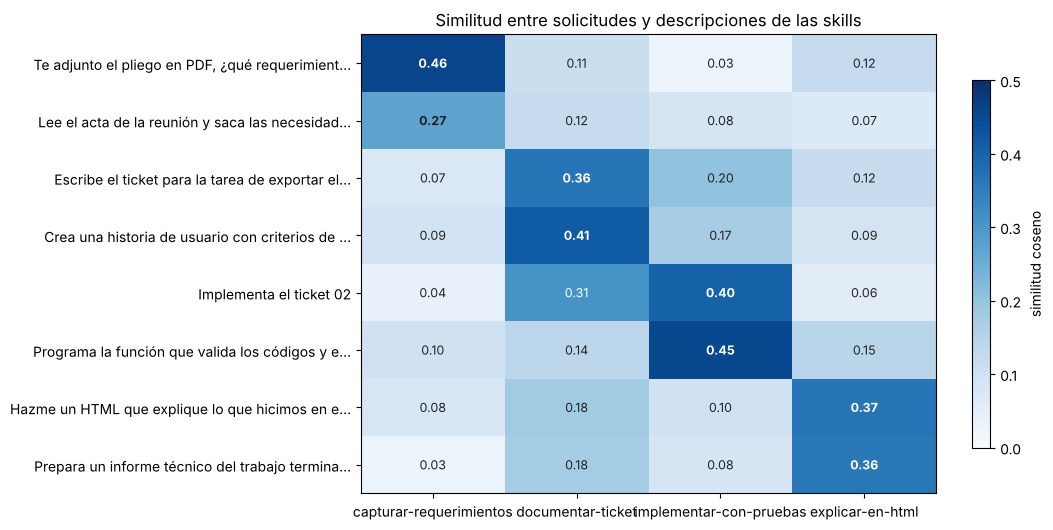

In [21]:
fig, ax = plt.subplots(figsize=(11, 5.4))
im = ax.imshow(similitud, cmap="Blues", vmin=0, vmax=0.5, aspect="auto")
ax.set_xticks(range(4), ORDEN)
ax.set_yticks(range(len(solicitudes)), [s if len(s) < 48 else s[:46] + "…" for s, _ in solicitudes])
for i in range(len(solicitudes)):
    for j in range(4):
        ax.text(j, i, f"{similitud[i, j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if similitud[i, j] > 0.3 else "#222",
                weight="bold" if j == similitud[i].argmax() else "normal")
plt.colorbar(im, ax=ax, label="similitud coseno", shrink=0.8)
ax.set_title("Similitud entre solicitudes y descripciones de las skills")
plt.tight_layout()
plt.savefig(IMG / "ej1_activacion_descripciones.png", dpi=150, bbox_inches="tight")
plt.show()

Las ocho solicitudes se asignan a la skill correcta, con un margen (diferencia entre la primera y la segunda similitud) de 0.097 en el caso más estrecho y de 0.15 a 0.34 en los demás. El caso más estrecho es *"Implementa el ticket 02"*: la palabra *ticket* aparece en la descripción de `documentar-ticket` y en la de `implementar-con-pruebas`, y la decide el verbo *implementa*. Es la situación esperable, porque las dos skills trabajan sobre el mismo objeto y se distinguen por la acción, y por eso cada descripción empieza con el verbo de lo que hace.

La prueba es solo un piso. Un agente real elige leyendo y razonando sobre la descripción, así que entiende sinónimos y contexto que TF‑IDF no capta; pero si las descripciones ya se separan sin ningún conocimiento del idioma, es poco probable que un modelo de lenguaje las confunda.

---

## 10. Demostración: el flujo completo sobre los documentos de la clase

La skill del numeral 4 debe leer y capturar requerimientos de *documentos provistos*. Los documentos provistos en el curso son los siete capítulos que entrega el profesor, y son una buena prueba porque mezclan todo lo que hace difícil esta tarea:

- La mayor parte del texto es **teoría**, llena de frases con *"se debe"* que no piden nada (*"la población debe ser lo suficientemente grande"*).
- Lo que se pide está en las secciones de **ejercicios**, escrito en **imperativo** (*"Tome una tabla de datos…"*, *"Simule el comportamiento…"*) y no con *"debe"*.
- Hay **reglas de selección** (*"Desarrolle tres ejercicios de los 6 propuestos"*, *"De los ejercicios 1 y 2, escoja 1"*).
- Las **condiciones de entrega** del curso están al final del capítulo 1, después de la bibliografía.
- Hay detalles que un lector apurado pasa por alto: dos ejercicios con el mismo número, una condición escondida dentro de otro ejercicio, una sugerencia pegada al final de otro numeral.

El flujo es el de la sección 3: se capturan los requerimientos de los siete documentos, se cruzan con lo que ya está entregado en el repositorio del equipo, se documentan como tickets los ejercicios pendientes del capítulo 7, se implementan los dos primeros tickets del numeral 4 (agente de mantenimiento) y se explica el resultado en HTML.

En cada paso se ejecutan los scripts de la skill correspondiente y se hace, en una celda marcada como tal, el trabajo de criterio que la skill le asigna al agente. La carpeta `demo/` se borra al empezar para que el resultado no dependa de ejecuciones anteriores.

In [22]:
if DEMO.exists():
    shutil.rmtree(DEMO)
PROY = DEMO / "proyecto"
for carpeta in [DEMO / "texto", DEMO / "candidatos", DEMO / "salida", PROY / "tickets", PROY / "tests"]:
    carpeta.mkdir(parents=True, exist_ok=True)

S_REQ = (SK / "capturar-requerimientos" / "scripts").resolve()
S_TIC = (SK / "documentar-ticket" / "scripts").resolve()
S_IMP = (SK / "implementar-con-pruebas" / "scripts").resolve()
S_HTM = (SK / "explicar-en-html" / "scripts").resolve()


def correr(script, *args, cwd=None, mostrar=True):
    "Ejecuta un script de una skill tal como lo haría el agente y devuelve (código, salida)."
    r = subprocess.run([sys.executable, str(script), *map(str, args)], cwd=cwd,
                       capture_output=True, text=True, encoding="utf-8")
    salida = (r.stdout + r.stderr).rstrip()
    if mostrar:
        print(salida)
    return r.returncode, salida

### 10.1 Documentos de entrada

Los siete PDF de la clase van en la carpeta `documentos_clase/`. En Colab, si la carpeta no existe, la celda pide subirlos. Para leer PDF, `extraer_texto.py` usa `pypdf`, que se instala si falta.

In [23]:
try:
    import pypdf
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pypdf"], check=True)
    import pypdf

DOCS = RAIZ / "documentos_clase"
if not any(DOCS.glob("*.pdf")) and "google.colab" in sys.modules:
    from google.colab import files
    DOCS.mkdir(exist_ok=True)
    for nombre, datos in files.upload().items():
        (DOCS / nombre).write_bytes(datos)

DOCUMENTOS = sorted(DOCS.glob("*.pdf"))
display(pd.DataFrame([{"documento": d.name, "páginas": len(pypdf.PdfReader(d).pages),
                       "tamaño (KB)": round(d.stat().st_size / 1024)} for d in DOCUMENTOS]))
print(f"{len(DOCUMENTOS)} documentos, {sum(len(pypdf.PdfReader(d).pages) for d in DOCUMENTOS)} páginas")

,documento,páginas,tamaño (KB)
0,1._INTRODUCCION_IA_26_2.pdf,10,687
1,2._Aut__matas_Celulares_26_2.pdf,17,1130
2,3_Algoritmos_Gen_ticos_26_2.pdf,25,1351
3,4._Programacion_Genetica_26_2.pdf,16,928
4,5_Redes_Neuronales1_2026_2.pdf,31,1651
5,6._Machine_Learning_26_2.pdf,22,1071
6,7._Gen_Ai_2026_2.pdf,23,852


7 documentos, 144 páginas


### 10.2 `capturar-requerimientos`: pasos 1 y 2 (scripts)

Para cada documento se extrae el texto y se detectan los candidatos, una ejecución por documento como indica la skill:

In [24]:
filas = []
for doc in DOCUMENTOS:
    _, texto = correr(S_REQ / "extraer_texto.py", doc.resolve(), mostrar=False)
    ruta_texto = DEMO / "texto" / f"{doc.stem}.txt"
    ruta_texto.write_text(texto + "\n", encoding="utf-8")
    ruta_json = DEMO / "candidatos" / f"{doc.stem}.json"
    correr(S_REQ / "detectar_requerimientos.py", ruta_texto, "--fuente", doc.name, "--json", ruta_json, mostrar=False)
    filas += json.loads(ruta_json.read_text(encoding="utf-8"))

candidatos = pd.DataFrame(filas)
candidatos["cap"] = candidatos["fuente"].str.extract(r"^(\d)").astype(int)
conteo = candidatos.pivot_table(index="fuente", columns="confianza", values="id", aggfunc="count", fill_value=0)
conteo = conteo[["alta", "media", "baja"]].rename_axis(columns=None)
conteo.loc["Total"] = conteo.sum()
display(conteo)

,alta,media,baja
fuente,,,
1._INTRODUCCION_IA_26_2.pdf,5,4,5
2._Aut__matas_Celulares_26_2.pdf,4,0,7
3_Algoritmos_Gen_ticos_26_2.pdf,7,0,42
4._Programacion_Genetica_26_2.pdf,5,10,14
5_Redes_Neuronales1_2026_2.pdf,5,0,9
6._Machine_Learning_26_2.pdf,6,9,19
7._Gen_Ai_2026_2.pdf,9,1,22
Total,41,24,118


De más de 150 candidatos, la mayoría son de confianza baja: frases de la teoría con *"debe"* o *"se requiere"*. Unos ejemplos de lo que el script marca y el agente descarta:

In [25]:
pd.set_option("display.max_colwidth", 110)
display(candidatos[candidatos.confianza == "baja"].sample(6, random_state=1)[["fuente", "pagina", "texto", "disparador"]])

,fuente,pagina,texto,disparador
143,6._Machine_Learning_26_2.pdf,20,"Otra manera en que se implementan prejuicios de género y raza se debe a cómo, de manera inconsciente, los ...",debe
74,4._Programacion_Genetica_26_2.pdf,2,"En otras palabras, ¿cómo podemos hacer para que los computadores hagan lo que tienen que hacer, sin necesi...",tienen que
85,4._Programacion_Genetica_26_2.pdf,4,Generar una población inicial de composiciones aleatorias de funciones y terminales del problema (es decir...,verbo en infinitivo
170,7._Gen_Ai_2026_2.pdf,22,"Por ejemplo, un modelo problemático capaz de generar contenido tóxico podría ser tolerable si se toman las...",podría
109,5_Redes_Neuronales1_2026_2.pdf,19,"Luego se pasa el error hacia atrás y se pondera a lo largo de cada capa , permitiendo calcular los cambios...",deben
59,3_Algoritmos_Gen_ticos_26_2.pdf,19,"Definir otros parámetros. En este caso vamos a parar cuando se hayan corrido 100 generaciones, M = 100 con...",verbo en infinitivo


Los de confianza alta y media, que son los que la skill manda revisar primero:

In [26]:
revisar = candidatos[candidatos.confianza != "baja"].copy()
revisar["texto"] = revisar["texto"].str.slice(0, 105)
display(revisar[["cap", "id", "tipo", "prioridad", "confianza", "pagina", "linea", "texto"]].reset_index(drop=True))

,cap,id,tipo,prioridad,confianza,pagina,linea,texto
0,1,C-06,RF,Debe,alta,9,22,"Pídale a varios LLMs de IAGen una definición de IA, compárelas con lo visto en el capítulo."
1,1,C-07,RF,Debe,alta,9,23,Dé una definición propia de inteligencia artificial.
2,1,C-08,RF,Debe,alta,9,24,Vea el video que se encuentra en https://www.youtube.com/watch?v=JsmKUCiPHUY&t=7s . Haga un análisis de l
3,1,C-09,RF,Debe,alta,9,26,Haga un resumen sobre Cosmos de NVIDIA
4,1,C-10,RF,Debe,alta,9,27,Investigue sobre los planes del gobierno con respecto a la IA.
...,...,...,...,...,...,...,...,...
60,7,C-28,RF,Debe,alta,23,13,Busque un repuesto (Código)
61,7,C-29,RF,Debe,alta,23,14,Consulte en el almacen (Código)
62,7,C-30,RF,Debe,alta,23,15,"Genere una orden de trabajo (falla, equipo)"
63,7,C-31,RF,Debe,alta,23,16,Actualice el historial de fallas


#### ¿Qué tan bien detecta?

Para medirlo hace falta una referencia que no salga del detector. La celda siguiente tiene, escrita a mano leyendo los siete PDF, la lista de lo que cada documento pide: sus ejercicios, sus reglas de selección y, en el capítulo 1, los cuatro ítems de la lista *"Con respecto al desarrollo del curso"*. Cada elemento se identifica por un fragmento de su texto. Con ella se calcula qué fracción de lo pedido encontró el detector (exhaustividad) y qué fracción de los candidatos de cada nivel es realmente un requerimiento (precisión).

In [27]:
REFERENCIA = {   # documento -> fragmentos que identifican cada cosa pedida (leídos a mano de los PDF)
    "1": ["Pídale a varios LLMs", "Dé una definición propia", "Vea el video", "resumen sobre Cosmos",
          "planes del gobierno", "grupo de whatsApp", "herramientas de IA Generativa, se deben",
          "sitio en GitHub", "Los programas deben presentarse"],
    "2": ["Observe sus comportamientos", "Suponga una enfermedad", "robot con tres sensores", "plano de una ciudad"],
    "3": ["Maximizar la función", "Verdadera democracia", "empresa proveedora de energía", "50 matrices",
          "50 palabras", "algoritmo de la dieta", "Desarrolle tres ejercicios de los 6"],
    "4": ["De los ejercicios 1 y 2, escoja 1", "circuito lógico", "robot que le entrega galletas",
          "Detección de fraudes", "Imagínese un problema"],
    "5": ["Tome una tabla de datos", "Use una red neuroanl", "Explique cada una de las funciones",
          "librería de Kaggle", "Punto libre"],
    "6": ["50.000 multiplicaciones", "algoritmo SVM", "K- Nearest", "árboles de decisión", "Bayes ingenuo",
          "De los últimos 4 ejercicios haga 3"],
    "7": ["defina sus propias skills", "RAG industrial", "documentos entregados para el curso",
          "agente de mantenimiento", "Busque un repuesto", "Consulte en el almacen", "Genere una orden de trabajo",
          "Actualice el historial", "ESP32"],
}
norma = lambda t: " ".join(str(t).split())
candidatos["es_requerimiento"] = [any(f in norma(t) for f in REFERENCIA[str(c)])
                                  for t, c in zip(candidatos.texto, candidatos.cap)]
encontrados = sum(any(f in norma(t) for t in candidatos[candidatos.cap == int(c)].texto) for c, fs in REFERENCIA.items() for f in fs)
total_ref = sum(len(fs) for fs in REFERENCIA.values())
print(f"Exhaustividad: {encontrados} de {total_ref} elementos pedidos aparecen entre los candidatos")
alta_media = candidatos[candidatos.confianza != "baja"]
print(f"Encontrados con confianza alta o media: "
      f"{sum(any(f in norma(t) for t in alta_media[alta_media.cap == int(c)].texto) for c, fs in REFERENCIA.items() for f in fs)} de {total_ref}\n")
por_obligacion = candidatos[candidatos.disparador.str.match(r"(?i)^(debe|deben|deber|se requiere|requiere|tiene|es necesario|se sugiere|podr|opcional)")]
print(f"Solo con la regla de obligación (la primera versión del detector): "
      f"{sum(any(f in norma(t) for t in por_obligacion[por_obligacion.cap == int(c)].texto) for c, fs in REFERENCIA.items() for f in fs)} de {total_ref}\n")
precision = candidatos.groupby("confianza")["es_requerimiento"].agg(candidatos="count", requerimientos="sum")
precision["precisión"] = (precision.requerimientos / precision.candidatos).round(2)
display(precision.loc[["alta", "media", "baja"]])

Exhaustividad: 45 de 45 elementos pedidos aparecen entre los candidatos
Encontrados con confianza alta o media: 45 de 45

Solo con la regla de obligación (la primera versión del detector): 5 de 45



,candidatos,requerimientos,precisión
confianza,,,
alta,41,41,1.00
media,24,4,0.17
baja,118,0,0.00


El detector encontró los 45 elementos de la referencia, todos con confianza alta o media. Leer esos dos niveles (65 candidatos de 183) basta para no perder nada de lo que piden los siete documentos.

- La confianza **alta** es exacta: sus 41 candidatos son los 34 ejercicios, los 4 sub-ítems del numeral 4 del capítulo 7 y las 3 reglas de selección.
- La **media** trae las 4 condiciones de entrega del capítulo 1, junto con 20 ítems de listas de pasos de la teoría (los pasos de la programación genética y de un proyecto de ML), que el agente descarta.
- La **baja**, 118 frases de la teoría con *"debe"*, *"se requiere"* o *"podría"*, no contiene ningún requerimiento.

La comparación con la regla de obligación sola muestra por qué hicieron falta las otras tres: con ella el detector habría encontrado 5 de los 45 elementos, porque los ejercicios están escritos en imperativo (*"Tome"*, *"Simule"*, *"Estudie"*) y casi nunca dicen *"debe"*. Una skill pensada para documentos de requisitos con *"el sistema debe…"* habría pasado por alto casi todo lo que pide el curso.

### 10.3 `capturar-requerimientos`: pasos 3 a 5 (trabajo del agente)

Sobre los candidatos de confianza alta y media, el agente hace lo que el script no puede:

- **Descartar** el ítem *"Crear un grupo de WhatsApp"*: está en la lista de condiciones del curso, pero es logística y no afecta ningún entregable.
- **Renumerar** el capítulo 2, que tiene dos ejercicios con el número 3, y dejar la duda como pregunta abierta.
- **Separar lo que está pegado.** El ejercicio 1 del capítulo 6 arrastra la frase *"En alguno de los siguientes problemas, usar datos de alguna entidad gubernamental"*, que es una condición para los ejercicios 2 a 5. El numeral 2 del capítulo 7 termina con *"…chatbot.2. Se sugiere usar Ollama"*, una sugerencia de tecnología.
- **Partir** el numeral 4 del capítulo 7 en la cabecera y sus cuatro funciones, y la condición de entrega del capítulo 1 en dos (presentar en Jupyter o Colab; incluir cada programa en un documento).
- **Marcar como Elegibles** los ejercicios de los capítulos con regla de selección, y registrar cada regla como restricción.
- **Convertir en preguntas** lo ambiguo: *"hacer 3 o 4"*, qué ejercicios son obligatorios cuando no hay regla, qué formato tienen el código de repuesto y la orden de trabajo.

El resultado es el archivo que recibe la siguiente skill:

In [28]:
%%writefile {DEMO}/salida/requerimientos.md
# Requerimientos: ejercicios y condiciones de entrega del curso Inteligencia Artificial y Minirobots

**Documentos analizados:** los siete capítulos del curso, semestre 2026-2 (1._INTRODUCCION_IA_26_2.pdf a 7._Gen_Ai_2026_2.pdf)
**Fecha del levantamiento:** 2026-10-04

## Requerimientos

| ID | Tipo | Prioridad | Requerimiento | Criterio de verificación | Fuente | Cita textual |
|---|---|---|---|---|---|---|
| RES-01 | RES | Debe | Los documentos y los programas se entregan en un sitio de GitHub | El repositorio tiene una carpeta por capítulo | Cap. 1, p.10 l.12 | "Crear un sitio en GitHub para la entrega de los documentos y los programas." |
| RES-02 | RES | Debe | Los programas se presentan en Jupyter Notebook o en Colab | Cada programa es un .ipynb | Cap. 1, p.10 l.13 | "Los programas deben presentarse en Jupyter Notebook o en COLAB." |
| RES-03 | RES | Debe | Cada programa se incluye en un documento que describe sus partes y sus resultados | Cada capítulo tiene un documento que cita sus programas | Cap. 1, p.10 l.13 | "Cada uno debe estar incluido en un documento que describa sus diferentes partes y sus resultados." |
| RES-04 | RES | Debe | Cuando se usa IA generativa se documentan las herramientas, los prompts y hasta qué punto sirvieron | Cada documento tiene una sección de uso de IA generativa | Cap. 1, p.10 l.9 | "se deben hacer comentarios sobre que herramientas utilizaron, los prompts y hasta qué punto les sirvió" |
| RF-1.1 | RF | Debe | Pedir a varios LLM una definición de IA y compararlas con el capítulo | Definiciones de al menos dos LLM y comparación | Cap. 1, p.9 l.22 | "Pídale a varios LLMs de IAGen una definición de IA" |
| RF-1.2 | RF | Debe | Dar una definición propia de inteligencia artificial | Definición escrita por el equipo | Cap. 1, p.9 l.23 | "Dé una definición propia de inteligencia artificial." |
| RF-1.3 | RF | Debe | Analizar el video indicado con respecto al documento | Análisis que relaciona video y capítulo | Cap. 1, p.9 l.24 | "Vea el video … Haga un análisis" |
| RF-1.4 | RF | Debe | Resumir Cosmos de NVIDIA | Resumen con fuentes | Cap. 1, p.9 l.26 | "Haga un resumen sobre Cosmos de NVIDIA" |
| RF-1.5 | RF | Debe | Investigar los planes del gobierno con respecto a la IA | Informe con fuentes | Cap. 1, p.9 l.27 | "Investigue sobre los planes del gobierno" |
| RF-2.1 | RF | Debe | Encontrar las reglas básicas de los comportamientos propios en casa, universidad y transporte | Reglas por escenario | Cap. 2, p.16 l.5 | "Observe sus comportamientos en la casa, en la universidad" |
| RF-2.2 | RF | Debe | Modelar una difusión con AC probabilísticos o simular un robot de dos ruedas que evita obstáculos | Simulación ejecutable | Cap. 2, p.16 l.7 | "desarrolle un modelo de difusión usando ACs probabilísticos" |
| RF-2.3 | RF | Debe | Simular un robot con tres sensores de distancia que evita 4 objetos aleatorios | El robot recorre el espacio sin chocar | Cap. 2, p.16 l.9 | "Simule el comportamiento de un robot con tres sensores" |
| RF-2.4 | RF | Debe | Dibujar diagramas de Voronoi de droguerías, salud y colegios de una ciudad y analizarlos | Un diagrama por servicio y análisis de faltantes | Cap. 2, p.16 l.11 | "Tome el plano de una ciudad pequeña" |
| RF-3.1 | RF | Elegible | Maximizar f(x) = x·sen(10πx) + 1 en [0, 1] con AG | Máximo comparado con una referencia | Cap. 3, p.24 l.6 | "Maximizar la función" |
| RF-3.2 | RF | Elegible | Repartir con AG el poder de 50 entidades entre 5 partidos según sus curules | Matriz de poder | Cap. 3, p.24 l.8 | "Verdadera democracia" |
| RF-3.3 | RF | Elegible | Encontrar con AG el despacho de energía de mínimo costo de transporte y generación | Despacho que cumple oferta y demanda | Cap. 3, p.24 l.17 | "Una empresa proveedora de energía eléctrica" |
| RF-3.4 | RF | Elegible | Evolucionar 50 matrices RGB de 120 × 180 hasta una imagen objetivo | Imagen final frente a la objetivo | Cap. 3, p.24 l.35 | "población de 50 matrices de 120 por 180" |
| RF-3.5 | RF | Elegible | Evolucionar 50 palabras habladas hasta una palabra objetivo | Palabra final audible | Cap. 3, p.24 l.39 | "población de 50 palabras" |
| RF-3.6 | RF | Elegible | Dieta multiobjetivo con AG: satisfacer la dieta con costo mínimo | Frente de soluciones costo-dieta | Cap. 3, p.25 l.1 | "Tome el algoritmo de la dieta y ahora incluya costos" |
| RES-3.S | RES | Debe | En el capítulo 3 se desarrollan tres de los seis ejercicios | Tres ejercicios entregados | Cap. 3, p.25 l.5 | "Desarrolle tres ejercicios de los 6 propuestos" |
| RF-4.1 | RF | Elegible | Diseñar con PG un circuito lógico (codificador de 7 segmentos) con una librería de Python | Terminales, funciones y aptitud descritos; circuito correcto | Cap. 4, p.15 l.15 | "obtener el diseño de un circuito lógico" |
| RF-4.2 | RF | Elegible | Programar con PG el recorrido de un robot que entrega galletas en una sala cuadrada | Terminales, funciones y aptitud descritos | Cap. 4, p.15 l.18 | "un robot que le entrega galletas" |
| RF-4.3 | RF | Elegible | Generar datos de transacciones, hacerlos realistas y encontrar con PG un modelo de fraude | Modelo evaluado | Cap. 4, p.16 l.3 | "Detección de fraudes" |
| RF-4.4 | RF | Elegible | Plantear un problema propio y resolverlo con PG | Problema y solución | Cap. 4, p.16 l.7 | "Imagínese un problema y desarróllelo por PG." |
| RES-4.S | RES | Debe | En el capítulo 4 se hace uno de los ejercicios 1 y 2, y el 3 o el 4 | Dos ejercicios según la regla | Cap. 4, p.15 l.14 | "De los ejercicios 1 y 2, escoja 1 para realizar; y hacer 3 o 4." |
| RF-5.1 | RF | Debe | Modelar con una red de dos capas ocultas una tabla de un experimento y predecir | Predicción con datos nuevos | Cap. 5, p.30 l.22 | "Tome una tabla de datos de un experimento cualquiera" |
| RF-5.2 | RF | Debe | Clasificar Fashion MNIST con dos capas ocultas y reportar la precisión | Precisión en prueba y conclusiones | Cap. 5, p.30 l.24 | "Use una red neuroanl con dos capas ocultas" |
| RF-5.3 | RF | Debe | Clasificar Fashion MNIST explicando cada función e instrucción | Explicación de cada función | Cap. 5, p.31 l.1 | "Explique cada una de las funciones" |
| RF-5.4 | RF | Debe | Modelar un dataset de Kaggle y probarlo con ejemplos de internet | Análisis de resultados con ejemplos externos | Cap. 5, p.31 l.4 | "De la librería de Kaggle para Python, baje un dataset" |
| RF-5.5 | RF | Debe | Punto libre | Ejercicio propio | Cap. 5, p.31 l.6 | "Punto libre." |
| RF-6.1 | RF | Debe | Entrenar un modelo con 50 000 multiplicaciones de matrices 2 × 2 y compararlo con el cálculo analítico y su costo | Comparación con 10 ejemplos y costo | Cap. 6, p.21 l.34 | "Conforme un data set con resultados de 50.000 multiplicaciones" |
| RF-6.2 | RF | Elegible | Estudiar y documentar SVM y adaptarlo a una aplicación | Aplicación documentada | Cap. 6, p.21 l.40 | "Estudie el algoritmo SVM" |
| RF-6.3 | RF | Elegible | Estudiar y documentar K-Nearest y adaptarlo a una aplicación | Aplicación documentada | Cap. 6, p.21 l.42 | "Estudie el algoritmo de K- Nearest" |
| RF-6.4 | RF | Elegible | Estudiar y documentar árboles de decisión y adaptarlos a una aplicación | Aplicación documentada | Cap. 6, p.22 l.1 | "Estudie el algoritmo de árboles de decisión" |
| RF-6.5 | RF | Elegible | Estudiar Bayes ingenuo y hacer un ejemplo documentado | Ejemplo documentado | Cap. 6, p.22 l.3 | "Estudie el algoritmo de Bayes ingenuo" |
| RES-6.S | RES | Debe | En el capítulo 6 se hacen tres de los ejercicios 2 a 5 | Tres ejercicios entregados | Cap. 6, p.22 l.3 | "De los últimos 4 ejercicios haga 3." |
| RES-6.D | RES | Debe | En alguno de los ejercicios 2 a 5 se usan datos de una entidad gubernamental | Fuente oficial citada | Cap. 6, p.21 l.34 | "En alguno de los siguientes problemas, usar datos de alguna entidad gubernamental." |
| RF-7.1 | RF | Debe | Definir cuatro skills propias con base en las de AI Hero: ticket, implementación, explicación en HTML y captura de requerimientos | Cuatro skills válidas | Cap. 7, p.23 l.4 | "defina sus propias skills. En principio 4" |
| RF-7.2 | RF | Debe | Construir un chatbot RAG sobre manuales técnicos de máquinas de planta | Respuestas citadas de los manuales | Cap. 7, p.23 l.9 | "RAG industrial. Descargue varios manuales técnicos" |
| RES-7.O | RES | Debería | Usar Ollama para el modelo de lenguaje del chatbot | Modelo local con Ollama | Cap. 7, p.23 l.9 | "Se sugiere usar Ollama." |
| RF-7.3 | RF | Debe | Construir un chatbot sobre los documentos entregados para el curso | Respuestas citadas de los capítulos | Cap. 7, p.23 l.11 | "Con base en los documentos entregados para el curso desarrollar un chatbot." |
| RF-7.4 | RF | Debe | Desarrollar un agente de mantenimiento | Agente que cumple RF-7.4a a RF-7.4d | Cap. 7, p.23 l.12 | "Desarrollar un agente de mantenimiento que:" |
| RF-7.4a | RF | Debe | El agente busca un repuesto por su código | Con un código se obtienen los datos del repuesto | Cap. 7, p.23 l.13 | "Busque un repuesto (Código)" |
| RF-7.4b | RF | Debe | El agente consulta el almacén por código | Con un código se obtiene la existencia | Cap. 7, p.23 l.14 | "Consulte en el almacen (Código)" |
| RF-7.4c | RF | Debe | El agente genera una orden de trabajo con la falla y el equipo | La orden contiene falla y equipo | Cap. 7, p.23 l.15 | "Genere una orden de trabajo (falla, equipo)" |
| RF-7.4d | RF | Debe | El agente actualiza el historial de fallas | El historial tiene un registro más por orden | Cap. 7, p.23 l.16 | "Actualice el historial de fallas" |
| RF-7.5 | RF | Debe | Analizar si una aplicación con un ESP32 puede usar un LLM y sus restricciones | Análisis de memoria, cómputo y conectividad | Cap. 7, p.23 l.17 | "un ESP32, podría usar un LLM? que restricciones tendría." |

## Supuestos

- S-01. Cuando un capítulo no da regla de selección (1, 2, 5 y 7), todos sus ejercicios son obligatorios (P-02).
- S-02. RES-01 a RES-04 aplican a todos los capítulos, aunque solo se enuncian en el capítulo 1.
- S-03. Los formatos que el numeral 7.4 no define los fija el equipo: código de repuesto REP-0000, orden de trabajo OT-0000 con estado "abierta" e historial en CSV (P-04).

## Preguntas abiertas

| # | Pregunta | Afecta a | Fuente |
|---|---|---|---|
| P-01 | En el capítulo 2 hay dos ejercicios numerados 3: ¿son dos ejercicios distintos? | RF-2.3, RF-2.4 | Cap. 2, p.16 l.9 y l.11 |
| P-02 | ¿Los capítulos sin regla de selección exigen todos sus ejercicios? | Capítulos 1, 2, 5 y 7 | — |
| P-03 | En el capítulo 4, ¿"hacer 3 o 4" significa uno de los dos? | RES-4.S | Cap. 4, p.15 l.14 |
| P-04 | ¿Qué formato tienen el código del repuesto, la orden de trabajo y el historial de fallas? | RF-7.4a a RF-7.4d | Cap. 7, p.23 l.13-16 |
| P-05 | La sugerencia de usar Ollama está en el numeral 2: ¿aplica también a los numerales 3 y 4? | RES-7.O, RF-7.3, RF-7.4 | Cap. 7, p.23 l.9 |

## Fuera de alcance

- Crear un grupo de WhatsApp (Cap. 1, p.10 l.8): logística del curso, no afecta los entregables.
- Cambiar un ejercicio del capítulo 6 por un problema propio (Cap. 6, p.22 l.3): es un permiso, no un requerimiento.

Writing ../demo/salida/requerimientos.md


In [29]:
lineas_req = [[c.strip() for c in l.strip().strip("|").split("|")] for l in
              (DEMO / "salida" / "requerimientos.md").read_text(encoding="utf-8").splitlines()
              if re.match(r"^\| (RF|RNF|RES)-[\w.]+ \|", l)]
req = pd.DataFrame(lineas_req, columns=["ID", "Tipo", "Prioridad", "Requerimiento", "Criterio", "Fuente", "Cita"])
display(req.groupby(["Tipo", "Prioridad"]).size().rename("requerimientos").to_frame())
print(f"{len(req)} requerimientos; "
      f"{(DEMO / 'salida' / 'requerimientos.md').read_text(encoding='utf-8').count('| P-0')} preguntas abiertas")

requerimientos
Tipo Prioridad                
RES  Debe                    8
     Debería                 1
RF   Debe                   24
     Elegible               14

47 requerimientos; 5 preguntas abiertas


#### Estado frente al repositorio

Con los requerimientos identificados se puede responder una pregunta útil para el equipo: qué está entregado y qué falta. El agente revisó el repositorio (`Bamp100310/IA-minirobots`, consultado el 2026-10-04) y cruzó cada capítulo con sus ejercicios, su regla de selección y las condiciones RES-02 y RES-03:

| Capítulo | Se pide | Entregado | Cumple la regla | RES-02 (Jupyter o Colab) | RES-03 (documento) |
|---|---|---|---|---|---|
| 1. Introducción | RF-1.1 a 1.5 | Los cinco, en el documento | Sí | No aplica (sin programas) | Sí |
| 2. Autómatas celulares | RF-2.1 a 2.4 (S-01, P-01) | 2.2, 2.3, 2.4 | Depende de P-02 | Sí | Sí |
| 3. Algoritmos genéticos | 3 de 6 (RES-3.S) | 3.1, 3.3, 3.6 | Sí | Sí | Sí |
| 4. Programación genética | 4.1 o 4.2, y 4.3 o 4.4 (RES-4.S) | 4.1, 4.3 | Sí | **No**: scripts `.py` | **No**: solo README |
| 5. Redes neuronales | RF-5.1 a 5.5 | Los cinco | Sí | Sí | Sí |
| 6. Machine Learning | 6.1 y 3 de 6.2 a 6.5 (RES-6.S) | 6.1, 6.2, 6.3, 6.4 (6.4 con datos oficiales, RES-6.D) | Sí | **No**: scripts `.py` | Sí |
| 7. IA generativa | RF-7.1 a 7.5 | 7.1 (este notebook) | Pendientes 7.2 a 7.5 | Sí | Sí |

Dos hallazgos que el equipo puede corregir: los capítulos 4 y 6 entregaron los programas como scripts de Python y no como notebooks, lo que no cumple RES-02, y el capítulo 4 no tiene un documento que describa los programas (RES-03). Lo pendiente del capítulo 7 es lo que pasa a la siguiente skill.

### 10.4 `documentar-ticket`

Siguiendo la skill, el trabajo pendiente del capítulo 7 se corta en rebanadas verticales. El numeral 4 se parte en tres tickets: las dos primeras son independientes entre sí y la tercera, que conecta un modelo de lenguaje con las funciones como herramientas, depende de ambas. El numeral 3, el chatbot sobre los documentos del curso, es un cuarto ticket independiente:

| Ticket | Entrega | Requerimientos | Bloqueado por |
|---|---|---|---|
| 01 | Consultar un repuesto y sus existencias | RF-7.4a, RF-7.4b | Ninguno |
| 02 | Registrar una orden de trabajo y actualizar el historial | RF-7.4c, RF-7.4d | Ninguno |
| 03 | Conversar con el agente usando las funciones como herramientas | RF-7.4, RES-7.O | 01 y 02 |
| 04 | Chatbot sobre los documentos del curso | RF-7.3, RES-7.O | Ninguno |

En este ejercicio se implementan los tickets 01 y 02; el 03 y el 04 quedan documentados para los numerales 3 y 4 del taller. Los numerales 2 y 5 no se documentan aquí.

In [30]:
%%writefile {DEMO}/proyecto/tickets/01-consultar-repuesto-y-existencias.md
# 01: Consultar un repuesto y sus existencias en el almacén

| Campo | Valor |
|---|---|
| **Tipo** | Funcionalidad |
| **Prioridad** | Debe |
| **Estimación** | 3 puntos |
| **Requerimientos** | RF-7.4a, RF-7.4b, RES-02, RES-03 |
| **Bloqueado por** | Ninguno |
| **Estado** | Listo para implementar |

## Contexto

El numeral 4 del ejercicio 7.11 pide un agente de mantenimiento que busque un repuesto por su código y consulte el almacén. Son las dos consultas básicas sobre las que trabajará después el modelo de lenguaje (ticket 03). El curso no define el formato del código ni los datos del catálogo (P-04); el equipo fija el formato REP-0000 (supuesto S-03).

## Objetivo

Dado un código de repuesto, el sistema devuelve su descripción, los equipos compatibles y la cantidad disponible, o explica por qué no puede hacerlo.

## Alcance

**Incluye**
- Búsqueda de un repuesto en el catálogo por su código.
- Consulta de la cantidad disponible en el almacén.
- Rechazo de códigos con formato distinto de REP-0000 (S-03).

**Fuera de alcance**
- Lectura del catálogo desde un archivo o base de datos: el curso no entrega datos de repuestos, así que se recibe como diccionario.
- Conversación en lenguaje natural (ticket 03).

## Interfaz acordada

- `buscar_repuesto(codigo, catalogo)` devuelve un diccionario con `codigo`, `descripcion` y `equipos`, o `None` si el código no está registrado. Lanza `ValueError` si el formato no es REP-0000.
- `consultar_existencias(codigo, almacen)` devuelve un entero con la cantidad disponible (0 si el repuesto no está en el almacén). Lanza `ValueError` si el formato no es REP-0000.

## Criterios de aceptación

- [ ] **CA-01.1** Dado un catálogo con REP-0042 "Motor DC 6 V" compatible con R-01 y R-07, cuando se busca REP-0042, entonces se obtienen esa descripción y esos dos equipos.
- [ ] **CA-01.2** Dado cualquiera de los códigos "42", "REP-42", "rep-0042" y "REP-00420", cuando se busca, entonces se lanza ValueError con un mensaje que menciona el formato REP-0000.
- [ ] **CA-01.3** Dado un código con formato válido que no está en el catálogo (REP-9999), cuando se busca, entonces el resultado es None.
- [ ] **CA-01.4** Dado un almacén con 3 unidades de REP-0042, cuando se consultan sus existencias, entonces el resultado es 3.
- [ ] **CA-01.5** Dado un código válido que no figura en el almacén, cuando se consultan sus existencias, entonces el resultado es 0.

## Casos borde

- Código con espacios alrededor (" REP-0042 "): se aceptan y se ignoran.
- Código en minúsculas: se rechaza, el formato fijado en S-03 es en mayúsculas.

## Dependencias y riesgos

- Riesgo: si P-04 se resuelve con otro formato de código, cambia la validación pero no la interfaz; el catálogo entra como diccionario para aislar su origen.

## Preguntas abiertas

- P-04 no bloquea este ticket: se trabaja con el supuesto S-03.

## Definición de terminado

- [ ] Todos los criterios de aceptación tienen una prueba automatizada que pasa.
- [ ] La suite completa pasa.
- [ ] El trabajo queda explicado (skill `explicar-en-html`).

Writing ../demo/proyecto/tickets/01-consultar-repuesto-y-existencias.md


In [31]:
%%writefile {DEMO}/proyecto/tickets/02-registrar-orden-y-actualizar-historial.md
# 02: Registrar una orden de trabajo y actualizar el historial de fallas

| Campo | Valor |
|---|---|
| **Tipo** | Funcionalidad |
| **Prioridad** | Debe |
| **Estimación** | 3 puntos |
| **Requerimientos** | RF-7.4c, RF-7.4d, RES-02, RES-03 |
| **Bloqueado por** | Ninguno |
| **Estado** | Listo para implementar |

## Contexto

El numeral 4 del ejercicio 7.11 pide que el agente genere una orden de trabajo con la falla y el equipo, y que actualice el historial de fallas. El curso no define el formato de la orden ni del historial (P-04); el equipo fija un consecutivo OT-0000, el estado inicial "abierta" y un historial en CSV (supuesto S-03).

## Objetivo

Al reportar una falla de un equipo, el sistema crea una orden de trabajo abierta con un consecutivo único y la agrega al historial de fallas.

## Alcance

**Incluye**
- Creación de la orden con equipo, falla, fecha, estado "abierta" y consecutivo OT-0000 (S-03).
- Registro de la orden en el historial en formato CSV (S-03).

**Fuera de alcance**
- Prioridad y cierre de órdenes: el numeral 4 no los pide.
- Conversación en lenguaje natural (ticket 03).

## Interfaz acordada

- `generar_orden(equipo, falla, ordenes, fecha=None)` devuelve un diccionario con `id`, `equipo`, `falla`, `fecha` y `estado`, y lo agrega a la lista `ordenes`. Lanza `ValueError` si el equipo o la falla están vacíos.
- `actualizar_historial(orden, ruta_csv)` agrega la orden al archivo CSV (lo crea con encabezado si no existe) y devuelve el número de registros del historial.

## Criterios de aceptación

- [ ] **CA-02.1** Dado que no hay órdenes, cuando se genera una para el equipo R-07 con la falla "rueda izquierda no gira", entonces la orden es OT-0001, queda "abierta" y conserva equipo y falla.
- [ ] **CA-02.2** Dado que existen OT-0001 y OT-0005, cuando se genera una nueva orden, entonces su identificador es OT-0006 y no repite ninguno existente.
- [ ] **CA-02.3** Dada una falla vacía o solo con espacios, cuando se intenta generar la orden, entonces se lanza ValueError y no se agrega ninguna orden.
- [ ] **CA-02.4** Dado que el archivo de historial no existe, cuando se registra una orden, entonces se crea con encabezado y 1 registro.
- [ ] **CA-02.5** Dado un historial con 1 registro, cuando se registra otra orden, entonces quedan 2 registros y el primero no cambia.

## Casos borde

- Identificadores con huecos (OT-0001, OT-0005): el siguiente es el mayor más uno.
- Texto de la falla con comas o tildes: el CSV debe conservarlo intacto.

## Dependencias y riesgos

- Si P-04 fija otro formato de historial, cambia la escritura del archivo pero no la interfaz.

## Preguntas abiertas

- P-04 no bloquea este ticket: se trabaja con el supuesto S-03.

## Definición de terminado

- [ ] Todos los criterios de aceptación tienen una prueba automatizada que pasa.
- [ ] La suite completa pasa.
- [ ] El trabajo queda explicado (skill `explicar-en-html`).

Writing ../demo/proyecto/tickets/02-registrar-orden-y-actualizar-historial.md


In [32]:
%%writefile {DEMO}/proyecto/tickets/03-conversar-con-el-agente.md
# 03: Conversar con el agente usando las funciones como herramientas

| Campo | Valor |
|---|---|
| **Tipo** | Funcionalidad |
| **Prioridad** | Debería |
| **Estimación** | 5 puntos |
| **Requerimientos** | RF-7.4, RES-7.O, RES-02, RES-03 |
| **Bloqueado por** | 01, 02 |
| **Estado** | Listo para implementar |

## Contexto

Con las consultas (ticket 01) y el registro de órdenes (ticket 02) disponibles, falta lo que hace de esto un agente: que el técnico pida las cosas en lenguaje natural y el modelo decida qué función llamar. El capítulo sugiere Ollama en el numeral 2 (RES-7.O); se adopta también aquí para que el agente funcione sin internet (P-05).

## Objetivo

El técnico describe la situación en una frase y el agente decide qué funciones llamar y responde con el resultado.

## Alcance

**Incluye**
- Registro de las cuatro funciones como herramientas del modelo.
- Ciclo de conversación: mensaje, llamadas a herramientas, respuesta.

**Fuera de alcance**
- Interfaz gráfica; la conversación es por consola.

## Interfaz acordada

- `atender(mensaje, estado)` devuelve el texto de la respuesta y la lista de herramientas llamadas, en orden.

## Criterios de aceptación

- [ ] **CA-03.1** Dado el mensaje "¿hay unidades del REP-0042?", cuando el agente lo atiende, entonces llama a consultar_existencias con REP-0042 y la respuesta contiene la cantidad.
- [ ] **CA-03.2** Dado el mensaje "el R-07 no gira la rueda izquierda", cuando el agente lo atiende, entonces llama a generar_orden y luego a actualizar_historial, y la respuesta contiene el identificador de la orden.
- [ ] **CA-03.3** Dado que no hay conexión a internet, cuando el agente atiende un mensaje, entonces responde usando el modelo local.

## Casos borde

- Mensajes con un código mal escrito: el agente transmite el error de formato al técnico.

## Dependencias y riesgos

- Los modelos pequeños de Ollama pueden elegir mal la herramienta; las pruebas deben fijar la semilla y la temperatura en 0.

## Preguntas abiertas

- P-05: si la sugerencia de Ollama no aplica al numeral 4, el modelo se cambia sin tocar la interfaz; no bloquea.

## Definición de terminado

- [ ] Todos los criterios de aceptación tienen una prueba automatizada que pasa.
- [ ] La suite completa pasa.
- [ ] El trabajo queda explicado (skill `explicar-en-html`).

Writing ../demo/proyecto/tickets/03-conversar-con-el-agente.md


In [33]:
%%writefile {DEMO}/proyecto/tickets/04-chatbot-documentos-del-curso.md
# 04: Responder preguntas sobre los documentos del curso, citando la fuente

| Campo | Valor |
|---|---|
| **Tipo** | Funcionalidad |
| **Prioridad** | Debe |
| **Estimación** | 5 puntos |
| **Requerimientos** | RF-7.3, RES-7.O, RES-02, RES-03 |
| **Bloqueado por** | Ninguno |
| **Estado** | Listo para implementar |

## Contexto

El numeral 3 del ejercicio 7.11 pide un chatbot construido con base en los documentos entregados para el curso, que son los mismos siete PDF de los que salieron estos requerimientos. La sección 7.7 del capítulo describe el esquema RAG: cargar los documentos, convertirlos en texto, partirlos, indexarlos y recuperar los fragmentos relevantes antes de generar la respuesta.

## Objetivo

Un estudiante hace una pregunta sobre el curso y recibe una respuesta basada en los documentos, con el documento y la página de donde sale.

## Alcance

**Incluye**
- Indexación de los PDF de una carpeta, por página.
- Recuperación de los fragmentos más relevantes y respuesta con un modelo local (RES-7.O, P-05).
- Citas de documento y página en cada respuesta.

**Fuera de alcance**
- Interfaz web; el chatbot se usa desde el notebook.
- Documentos distintos de PDF.

## Interfaz acordada

- `indexar(carpeta)` devuelve un índice con los fragmentos de todos los PDF de la carpeta y su documento y página de origen.
- `responder(pregunta, indice)` devuelve el texto de la respuesta y la lista de citas (documento, página) en que se basa.

## Criterios de aceptación

- [ ] **CA-04.1** Dado el índice de los siete documentos, cuando se pregunta cuántos ejercicios del capítulo 3 hay que desarrollar, entonces la respuesta dice tres y cita 3_Algoritmos_Gen_ticos_26_2.pdf, página 25.
- [ ] **CA-04.2** Dado el índice, cuando se pregunta qué es un autómata celular, entonces la respuesta cita al menos una página de 2._Aut__matas_Celulares_26_2.pdf.
- [ ] **CA-04.3** Dada una pregunta sin relación con el curso, cuando se responde, entonces el chatbot dice que no está en los documentos y no devuelve citas.
- [ ] **CA-04.4** Dado un PDF nuevo en la carpeta, cuando se vuelve a indexar, entonces sus páginas aparecen como citas posibles.

## Casos borde

- Texto extraído con espacios de más ("C uando", "requerim ientos"): la búsqueda no debe depender de palabras exactas.
- Preguntas que mezclan dos capítulos: la respuesta cita ambos.

## Dependencias y riesgos

- Reutiliza la extracción de texto de la skill capturar-requerimientos.
- Los modelos pequeños pueden responder sin usar el contexto; los criterios verifican las citas, no la redacción.

## Preguntas abiertas

- P-05: si la sugerencia de Ollama no aplica al numeral 3, el modelo se cambia sin tocar la interfaz; no bloquea.

## Definición de terminado

- [ ] Todos los criterios de aceptación tienen una prueba automatizada que pasa.
- [ ] La suite completa pasa.
- [ ] El trabajo queda explicado (skill `explicar-en-html`).

Writing ../demo/proyecto/tickets/04-chatbot-documentos-del-curso.md


Se validan los cuatro tickets con el script de la skill. Para comprobar que el validador sirve, se le pasa también un ticket escrito "como siempre", que es como suelen quedar cuando nadie usa la plantilla:

In [34]:
TICKETS = sorted((PROY / "tickets").glob("*.md"))
codigo, _ = correr(S_TIC / "validar_ticket.py", *TICKETS)
print("Código de salida:", codigo)

malo = DEMO / "salida" / "ticket_mal_escrito.md"
malo.write_text("""# Arreglar lo del almacén

| Campo | Valor |
|---|---|
| **Tipo** | Funcionalidad |
| **Estimación** | 13 puntos |

## Contexto

El almacén no funciona bien.

## Criterios de aceptación

- [ ] **CA-1** Que la búsqueda sea rápida y funcione correctamente.
""", encoding="utf-8")
print()
codigo, _ = correr(S_TIC / "validar_ticket.py", malo)
print("Código de salida:", codigo)

01-consultar-repuesto-y-existencias.md: VÁLIDO  (5 criterios de aceptación)
02-registrar-orden-y-actualizar-historial.md: VÁLIDO  (5 criterios de aceptación)
03-conversar-con-el-agente.md: VÁLIDO  (3 criterios de aceptación)
04-chatbot-documentos-del-curso.md: VÁLIDO  (4 criterios de aceptación)
Código de salida: 0

ticket_mal_escrito.md: CON ERRORES  (1 criterios de aceptación)
  ERROR  Falta la sección '## Objetivo'.
  ERROR  Falta la sección '## Alcance'.
  ERROR  Falta la sección '## Interfaz acordada'.
  ERROR  Falta la sección '## Casos borde'.
  ERROR  Falta la sección '## Dependencias y riesgos'.
  ERROR  Falta la sección '## Preguntas abiertas'.
  ERROR  Falta la sección '## Definición de terminado'.
  ERROR  Falta el campo 'Prioridad' en la tabla de metadatos.
  ERROR  Falta el campo 'Requerimientos' en la tabla de metadatos.
  ERROR  Falta el campo 'Bloqueado por' en la tabla de metadatos.
  ERROR  Falta el campo 'Estado' en la tabla de metadatos.
  ERROR  Estimación 13: use

Los cuatro tickets son válidos y el mal escrito acumula errores concretos: le faltan siete secciones y cuatro campos, la estimación de 13 puntos indica que hay que partirlo, el criterio no tiene la forma *Dado/Cuando/Entonces* y el validador señala que *"rápida"* y *"correctamente"* no se pueden verificar.

### 10.5 `implementar-con-pruebas`

Se prepara el proyecto como indica la skill cuando no hay uno previo: Python, `pytest` y un `pytest.ini` con `pythonpath = .`. Luego, para cada ticket, se crea la **interfaz acordada** con `NotImplementedError`:

In [35]:
(PROY / "pytest.ini").write_text("[pytest]\npythonpath = .\ntestpaths = tests\n", encoding="utf-8")
print((PROY / "pytest.ini").read_text(encoding="utf-8"))

[pytest]
pythonpath = .
testpaths = tests



In [36]:
%%writefile {DEMO}/proyecto/repuestos.py
"""Consulta de repuestos y existencias (ticket 01). Interfaz acordada, sin implementar."""


def buscar_repuesto(codigo, catalogo):
    raise NotImplementedError


def consultar_existencias(codigo, almacen):
    raise NotImplementedError

Writing ../demo/proyecto/repuestos.py


Las pruebas del ticket 01 traducen cada criterio, con su identificador en el docstring. Los valores esperados son los del ticket (*"Motor DC 6 V"*, 3 unidades, `None`), no algo recalculado. Las pruebas usan solo la interfaz pública.

In [37]:
%%writefile {DEMO}/proyecto/tests/test_repuestos.py
import pytest

from repuestos import buscar_repuesto, consultar_existencias

CATALOGO = {
    "REP-0042": {"descripcion": "Motor DC 6 V", "equipos": ["R-01", "R-07"]},
    "REP-0100": {"descripcion": "Sensor ultrasónico HC-SR04", "equipos": ["R-03"]},
}
ALMACEN = {"REP-0042": 3, "REP-0100": 12}


def test_busqueda_devuelve_descripcion_y_equipos():
    """CA-01.1"""
    repuesto = buscar_repuesto("REP-0042", CATALOGO)
    assert repuesto["descripcion"] == "Motor DC 6 V"
    assert repuesto["equipos"] == ["R-01", "R-07"]


@pytest.mark.parametrize("codigo", ["42", "REP-42", "rep-0042", "REP-00420"])
def test_rechaza_codigo_con_formato_invalido(codigo):
    """CA-01.2"""
    with pytest.raises(ValueError, match="REP-0000"):
        buscar_repuesto(codigo, CATALOGO)


def test_codigo_valido_no_registrado_devuelve_none():
    """CA-01.3"""
    assert buscar_repuesto("REP-9999", CATALOGO) is None


def test_existencias_de_repuesto_en_almacen():
    """CA-01.4"""
    assert consultar_existencias("REP-0042", ALMACEN) == 3


def test_existencias_de_repuesto_ausente_es_cero():
    """CA-01.5"""
    assert consultar_existencias("REP-0777", ALMACEN) == 0

Writing ../demo/proyecto/tests/test_repuestos.py


**Fase roja.** Cada prueba se ejecuta por separado con `ciclo.py`. Las parejas criterio → prueba no se escriben a mano: salen del script de trazabilidad de la misma skill, que lee el ticket y los docstrings.

En una sesión real el agente alterna rojo y verde criterio por criterio. Aquí, para no repetir el módulo completo cinco veces, se agrupan por ticket: todas las pruebas del ticket en rojo y luego todas en verde. Cada prueba sigue pasando por las dos fases y la bitácora lo registra.

In [38]:
sys.path.insert(0, str(S_IMP))
import trazabilidad


def fase(ticket, nombre_fase):
    "Ejecuta con ciclo.py cada prueba de cada criterio del ticket en la fase indicada."
    archivo_pruebas = {"01": "tests/test_repuestos.py", "02": "tests/test_ordenes.py"}[ticket.name[:2]]
    for criterio, _, pruebas in trazabilidad.matriz(ticket, PROY / "tests"):
        for prueba in pruebas:
            nombre = prueba.split("::")[1]
            correr(S_IMP / "ciclo.py", "--fase", nombre_fase, "--prueba", f"{archivo_pruebas}::{nombre}",
                   "--criterio", criterio, cwd=PROY)

T01, T02 = TICKETS[0], TICKETS[1]
fase(T01, "rojo")

OK [ROJO ] CA-01.1  tests/test_repuestos.py::test_busqueda_devuelve_descripcion_y_equipos: falla. Falla por la razón correcta.


OK [ROJO ] CA-01.2  tests/test_repuestos.py::test_rechaza_codigo_con_formato_invalido: falla. Falla por la razón correcta.


OK [ROJO ] CA-01.3  tests/test_repuestos.py::test_codigo_valido_no_registrado_devuelve_none: falla. Falla por la razón correcta.


OK [ROJO ] CA-01.4  tests/test_repuestos.py::test_existencias_de_repuesto_en_almacen: falla. Falla por la razón correcta.


OK [ROJO ] CA-01.5  tests/test_repuestos.py::test_existencias_de_repuesto_ausente_es_cero: falla. Falla por la razón correcta.


Las cinco pruebas fallan, y por la razón correcta (`NotImplementedError`, no un error de importación). Para comprobar que `ciclo.py` detecta la razón equivocada, se ejecuta una prueba contra un módulo que no existe; el resultado se registra en una bitácora aparte para no mezclarlo con la del proyecto:

In [39]:
(PROY / "tests" / "test_sonda.py").write_text("from modulo_inexistente import f\n\ndef test_sonda():\n    assert f() == 1\n",
                                              encoding="utf-8")
correr(S_IMP / "ciclo.py", "--fase", "rojo", "--prueba", "tests/test_sonda.py::test_sonda",
       "--bitacora", DEMO.resolve() / "salida" / "bitacora_sonda.json", cwd=PROY, mostrar=False)
print(json.loads((DEMO / "salida" / "bitacora_sonda.json").read_text(encoding="utf-8"))[0]["mensaje"])
(PROY / "tests" / "test_sonda.py").unlink()

Falla por la razón equivocada (ModuleNotFoundError); cree primero la interfaz.


**Fase verde.** Se escribe la implementación mínima que satisface los criterios:

In [40]:
%%writefile {DEMO}/proyecto/repuestos.py
"""Consulta de repuestos y existencias (ticket 01)."""
import re

FORMATO = re.compile(r"REP-\d{4}")


def _normalizar(codigo):
    "Quita espacios alrededor y exige el formato REP-0000 (supuesto S-03)."
    codigo = str(codigo).strip()
    if not FORMATO.fullmatch(codigo):
        raise ValueError(f"Código '{codigo}' inválido: se espera el formato REP-0000.")
    return codigo


def buscar_repuesto(codigo, catalogo):
    "Datos del repuesto, o None si el código no está en el catálogo (RF-7.4a)."
    codigo = _normalizar(codigo)
    datos = catalogo.get(codigo)
    if datos is None:
        return None
    return {"codigo": codigo, "descripcion": datos["descripcion"], "equipos": list(datos["equipos"])}


def consultar_existencias(codigo, almacen):
    "Unidades disponibles en el almacén; 0 si el repuesto no figura (RF-7.4b)."
    return int(almacen.get(_normalizar(codigo), 0))

Overwriting ../demo/proyecto/repuestos.py


In [41]:
fase(T01, "verde")

OK [VERDE] CA-01.1  tests/test_repuestos.py::test_busqueda_devuelve_descripcion_y_equipos: pasa. La prueba pasa.


OK [VERDE] CA-01.2  tests/test_repuestos.py::test_rechaza_codigo_con_formato_invalido: pasa. La prueba pasa.


OK [VERDE] CA-01.3  tests/test_repuestos.py::test_codigo_valido_no_registrado_devuelve_none: pasa. La prueba pasa.


OK [VERDE] CA-01.4  tests/test_repuestos.py::test_existencias_de_repuesto_en_almacen: pasa. La prueba pasa.


OK [VERDE] CA-01.5  tests/test_repuestos.py::test_existencias_de_repuesto_ausente_es_cero: pasa. La prueba pasa.


Las cinco pruebas pasan. El mismo ciclo para el ticket 02. Las pruebas del historial usan `tmp_path` de `pytest`, una carpeta temporal distinta para cada prueba, para no depender de archivos reales ni del orden de ejecución, y la fecha se pasa explícitamente para no depender del reloj:

In [42]:
%%writefile {DEMO}/proyecto/ordenes.py
"""Órdenes de trabajo e historial de fallas (ticket 02). Interfaz acordada, sin implementar."""


def generar_orden(equipo, falla, ordenes, fecha=None):
    raise NotImplementedError


def actualizar_historial(orden, ruta_csv):
    raise NotImplementedError

Writing ../demo/proyecto/ordenes.py


In [43]:
%%writefile {DEMO}/proyecto/tests/test_ordenes.py
import csv

import pytest

from ordenes import actualizar_historial, generar_orden

FECHA = "2026-10-02"


def test_primera_orden_es_ot_0001_y_queda_abierta():
    """CA-02.1"""
    ordenes = []
    orden = generar_orden("R-07", "rueda izquierda no gira", ordenes, fecha=FECHA)
    assert orden == {"id": "OT-0001", "equipo": "R-07", "falla": "rueda izquierda no gira",
                     "fecha": FECHA, "estado": "abierta"}
    assert ordenes == [orden]


def test_consecutivo_sigue_al_mayor_existente():
    """CA-02.2"""
    ordenes = [{"id": "OT-0001"}, {"id": "OT-0005"}]
    orden = generar_orden("R-03", "sensor sin lectura", ordenes, fecha=FECHA)
    assert orden["id"] == "OT-0006"
    assert len({o["id"] for o in ordenes}) == 3


@pytest.mark.parametrize("falla", ["", "   "])
def test_falla_vacia_se_rechaza_sin_crear_orden(falla):
    """CA-02.3"""
    ordenes = []
    with pytest.raises(ValueError):
        generar_orden("R-07", falla, ordenes, fecha=FECHA)
    assert ordenes == []


def test_historial_inexistente_se_crea_con_encabezado(tmp_path):
    """CA-02.4"""
    ruta = tmp_path / "historial.csv"
    orden = generar_orden("R-07", "rueda izquierda no gira", [], fecha=FECHA)
    assert actualizar_historial(orden, ruta) == 1
    with open(ruta, encoding="utf-8", newline="") as f:
        filas = list(csv.reader(f))
    assert filas[0] == ["fecha", "orden", "equipo", "falla", "estado"]
    assert filas[1] == [FECHA, "OT-0001", "R-07", "rueda izquierda no gira", "abierta"]


def test_segundo_registro_conserva_el_primero(tmp_path):
    """CA-02.5"""
    ruta = tmp_path / "historial.csv"
    ordenes = []
    actualizar_historial(generar_orden("R-07", "rueda izquierda no gira", ordenes, fecha=FECHA), ruta)
    primera = ruta.read_text(encoding="utf-8")
    total = actualizar_historial(generar_orden("R-02", "batería, no carga", ordenes, fecha=FECHA), ruta)
    assert total == 2
    assert ruta.read_text(encoding="utf-8").startswith(primera)

Writing ../demo/proyecto/tests/test_ordenes.py


In [44]:
fase(T02, "rojo")

OK [ROJO ] CA-02.1  tests/test_ordenes.py::test_primera_orden_es_ot_0001_y_queda_abierta: falla. Falla por la razón correcta.


OK [ROJO ] CA-02.2  tests/test_ordenes.py::test_consecutivo_sigue_al_mayor_existente: falla. Falla por la razón correcta.


OK [ROJO ] CA-02.3  tests/test_ordenes.py::test_falla_vacia_se_rechaza_sin_crear_orden: falla. Falla por la razón correcta.


OK [ROJO ] CA-02.4  tests/test_ordenes.py::test_historial_inexistente_se_crea_con_encabezado: falla. Falla por la razón correcta.


OK [ROJO ] CA-02.5  tests/test_ordenes.py::test_segundo_registro_conserva_el_primero: falla. Falla por la razón correcta.


In [45]:
%%writefile {DEMO}/proyecto/ordenes.py
"""Órdenes de trabajo e historial de fallas (ticket 02)."""
import csv
from datetime import date
from pathlib import Path

COLUMNAS = ["fecha", "orden", "equipo", "falla", "estado"]


def generar_orden(equipo, falla, ordenes, fecha=None):
    "Crea una orden abierta con consecutivo único y la agrega a la lista (RF-7.4c, S-03)."
    equipo, falla = str(equipo).strip(), str(falla).strip()
    if not equipo or not falla:
        raise ValueError("La orden necesita el equipo y la descripción de la falla.")
    mayor = max((int(o["id"].split("-")[1]) for o in ordenes), default=0)
    orden = {"id": f"OT-{mayor + 1:04d}", "equipo": equipo, "falla": falla,
             "fecha": fecha or date.today().isoformat(), "estado": "abierta"}
    ordenes.append(orden)
    return orden


def actualizar_historial(orden, ruta_csv):
    "Agrega la orden al historial CSV, creándolo si no existe. Devuelve el total de registros (RF-7.4d)."
    ruta = Path(ruta_csv)
    nuevo = not ruta.exists()
    with open(ruta, "a", encoding="utf-8", newline="") as f:
        escritor = csv.writer(f)
        if nuevo:
            escritor.writerow(COLUMNAS)
        escritor.writerow([orden["fecha"], orden["id"], orden["equipo"], orden["falla"], orden["estado"]])
    with open(ruta, encoding="utf-8", newline="") as f:
        return sum(1 for _ in csv.reader(f)) - 1

Overwriting ../demo/proyecto/ordenes.py


In [46]:
fase(T02, "verde")

OK [VERDE] CA-02.1  tests/test_ordenes.py::test_primera_orden_es_ot_0001_y_queda_abierta: pasa. La prueba pasa.


OK [VERDE] CA-02.2  tests/test_ordenes.py::test_consecutivo_sigue_al_mayor_existente: pasa. La prueba pasa.


OK [VERDE] CA-02.3  tests/test_ordenes.py::test_falla_vacia_se_rechaza_sin_crear_orden: pasa. La prueba pasa.


OK [VERDE] CA-02.4  tests/test_ordenes.py::test_historial_inexistente_se_crea_con_encabezado: pasa. La prueba pasa.


OK [VERDE] CA-02.5  tests/test_ordenes.py::test_segundo_registro_conserva_el_primero: pasa. La prueba pasa.


### 10.6 Cierre de la implementación: suite, trazabilidad y bitácora

Los tres pasos finales de la skill: suite completa, trazabilidad y revisión de la bitácora.

In [47]:
r = subprocess.run([sys.executable, "-m", "pytest", "-v", "--color=no", "-p", "no:cacheprovider"], cwd=PROY,
                   capture_output=True, text=True, encoding="utf-8")
SALIDA_PYTEST = r.stdout
print("\n".join(l for l in SALIDA_PYTEST.splitlines() if "::" in l or "passed" in l or "failed" in l))
print("\nCódigo de salida de pytest:", r.returncode)

tests/test_ordenes.py::test_primera_orden_es_ot_0001_y_queda_abierta PASSED [  7%]
tests/test_ordenes.py::test_consecutivo_sigue_al_mayor_existente PASSED  [ 14%]
tests/test_ordenes.py::test_falla_vacia_se_rechaza_sin_crear_orden[] PASSED [ 21%]
tests/test_ordenes.py::test_falla_vacia_se_rechaza_sin_crear_orden[   ] PASSED [ 28%]
tests/test_ordenes.py::test_historial_inexistente_se_crea_con_encabezado PASSED [ 35%]
tests/test_ordenes.py::test_segundo_registro_conserva_el_primero PASSED  [ 42%]
tests/test_repuestos.py::test_busqueda_devuelve_descripcion_y_equipos PASSED [ 50%]
tests/test_repuestos.py::test_rechaza_codigo_con_formato_invalido[42] PASSED [ 57%]
tests/test_repuestos.py::test_rechaza_codigo_con_formato_invalido[REP-42] PASSED [ 64%]
tests/test_repuestos.py::test_rechaza_codigo_con_formato_invalido[rep-0042] PASSED [ 71%]
tests/test_repuestos.py::test_rechaza_codigo_con_formato_invalido[REP-00420] PASSED [ 78%]
tests/test_repuestos.py::test_codigo_valido_no_registrado_devuel

In [48]:
for t in (T01, T02):
    print(f"--- {t.name}")
    correr(S_IMP / "trazabilidad.py", t, PROY / "tests")

--- 01-consultar-repuesto-y-existencias.md
CA-01.1  -> test_repuestos.py::test_busqueda_devuelve_descripcion_y_equipos
CA-01.2  -> test_repuestos.py::test_rechaza_codigo_con_formato_invalido
CA-01.3  -> test_repuestos.py::test_codigo_valido_no_registrado_devuelve_none
CA-01.4  -> test_repuestos.py::test_existencias_de_repuesto_en_almacen
CA-01.5  -> test_repuestos.py::test_existencias_de_repuesto_ausente_es_cero

5 de 5 criterios cubiertos.
--- 02-registrar-orden-y-actualizar-historial.md
CA-02.1  -> test_ordenes.py::test_primera_orden_es_ot_0001_y_queda_abierta
CA-02.2  -> test_ordenes.py::test_consecutivo_sigue_al_mayor_existente
CA-02.3  -> test_ordenes.py::test_falla_vacia_se_rechaza_sin_crear_orden
CA-02.4  -> test_ordenes.py::test_historial_inexistente_se_crea_con_encabezado
CA-02.5  -> test_ordenes.py::test_segundo_registro_conserva_el_primero

5 de 5 criterios cubiertos.


In [49]:
bitacora = pd.DataFrame(json.loads((PROY / "bitacora_tdd.json").read_text(encoding="utf-8")))
bitacora["prueba"] = bitacora["prueba"].str.split("::").str[1]
resumen_tdd = (bitacora.pivot_table(index=["criterio", "prueba"], columns="fase", values="resultado", aggfunc="first")
               [["rojo", "verde"]].reset_index().rename_axis(columns=None))
resumen_tdd["ciclo completo"] = (resumen_tdd["rojo"] == "falla") & (resumen_tdd["verde"] == "pasa")
display(resumen_tdd)
print(f"Ejecuciones registradas: {len(bitacora)}; todas como se esperaba: {bool(bitacora['cumple'].all())}")

,criterio,prueba,rojo,verde,ciclo completo
0,CA-01.1,test_busqueda_devuelve_descripcion_y_equipos,falla,pasa,True
1,CA-01.2,test_rechaza_codigo_con_formato_invalido,falla,pasa,True
2,CA-01.3,test_codigo_valido_no_registrado_devuelve_none,falla,pasa,True
3,CA-01.4,test_existencias_de_repuesto_en_almacen,falla,pasa,True
4,CA-01.5,test_existencias_de_repuesto_ausente_es_cero,falla,pasa,True
5,CA-02.1,test_primera_orden_es_ot_0001_y_queda_abierta,falla,pasa,True
6,CA-02.2,test_consecutivo_sigue_al_mayor_existente,falla,pasa,True
7,CA-02.3,test_falla_vacia_se_rechaza_sin_crear_orden,falla,pasa,True
8,CA-02.4,test_historial_inexistente_se_crea_con_encabezado,falla,pasa,True
9,CA-02.5,test_segundo_registro_conserva_el_primero,falla,pasa,True


Ejecuciones registradas: 20; todas como se esperaba: True


Los 10 criterios de los dos tickets tienen prueba, cada prueba se vio fallar por la razón correcta antes de pasar, y la suite completa (14 casos, porque dos pruebas están parametrizadas) pasa. Los tickets 03 y 04 no se cruzan porque no se implementaron.

### 10.7 `explicar-en-html`

El último paso arma `contenido.json` con la evidencia generada arriba (salida de `pytest`, bitácora, código fuente de los módulos, tickets) y lo convierte en HTML con el script de la skill. Lo único que se escribe a mano son los textos explicativos; las tablas y cifras se leen de los archivos.

In [50]:
def funcion_fuente(ruta, nombre):
    "Fragmento de código de una función, leído del archivo real."
    texto = Path(ruta).read_text(encoding="utf-8")
    nodo = next(n for n in ast.parse(texto).body if isinstance(n, ast.FunctionDef) and n.name == nombre)
    return "\n".join(texto.splitlines()[nodo.lineno - 1: nodo.end_lineno])


resumen_pytest = SALIDA_PYTEST.strip().splitlines()[-1]          # p. ej. "== 15 passed in 0.13s =="
aprobados = int((re.search(r"(\d+) passed", resumen_pytest) or [0, 0])[1])
fallidos = int((re.search(r"(\d+) failed", resumen_pytest) or [0, 0])[1])
casos = range(aprobados + fallidos)
tiempo = re.search(r"in ([\d.]+)s", SALIDA_PYTEST).group(1)
criterios = {c: f for t in (T01, T02) for c, f, _ in trazabilidad.matriz(t, PROY / "tests")}
filas_pruebas = [[f["criterio"], criterios[f["criterio"]][:90] + "…", f["prueba"],
                  "OK falla" if f["rojo"] == "falla" else "FALLA", "OK pasa" if f["verde"] == "pasa" else "FALLA"]
                 for _, f in resumen_tdd.iterrows()]
req_ticket = req[req.ID.str.startswith("RF-7.4") | req.ID.isin(["RES-02", "RES-03"])]

contenido = {
    "titulo": "Agente de mantenimiento: consultas de repuestos y órdenes de trabajo",
    "subtitulo": "Numeral 4 del ejercicio 7.11 · tickets 01 y 02 · flujo de skills del Ejercicio 7.11.1",
    "metricas": [
        {"valor": str(len(req)), "etiqueta": f"requerimientos capturados de los {len(DOCUMENTOS)} documentos del curso"},
        {"valor": "2 de 4", "etiqueta": "tickets implementados (03 y 04 quedan documentados)"},
        {"valor": f"{len(criterios)}/{len(criterios)}", "etiqueta": "criterios de aceptación con prueba"},
        {"valor": f"{aprobados}/{len(casos)}", "etiqueta": f"casos de prueba que pasan ({tiempo} s)"},
    ],
    "secciones": [
        {"id": "resumen", "titulo": "Resumen", "bloques": [
            {"tipo": "parrafo", "texto": "Se implementaron las dos primeras rebanadas del agente de mantenimiento: "
             "**consultar un repuesto y sus existencias** (ticket 01) y **registrar una orden de trabajo en el historial "
             f"de fallas** (ticket 02). Los {len(criterios)} criterios de aceptación tienen una prueba automatizada; "
             f"los {len(casos)} casos pasan y cada uno se vio fallar antes de escribir el código que lo satisface."},
            {"tipo": "nota", "clase": "ok", "texto": "Listo para el ticket 03, que conecta estas funciones con un modelo "
             "de lenguaje local (Ollama) como herramientas del agente."}]},
        {"id": "problema", "titulo": "Problema y contexto", "bloques": [
            {"tipo": "parrafo", "texto": f"La skill `capturar-requerimientos` leyó los {len(DOCUMENTOS)} documentos del curso "
             f"y obtuvo {len(req)} requerimientos. De ellos, el numeral 4 del capítulo 7 pide un **agente de mantenimiento** "
             "que busque un repuesto, consulte el almacén, genere una orden de trabajo y actualice el historial de fallas; "
             "el capítulo 1 fija las condiciones de entrega. Estos son los requerimientos que cubren los tickets 01 y 02:"},
            {"tipo": "tabla", "encabezados": ["ID", "Requerimiento", "Fuente", "Cita"],
             "filas": [[r.ID, r.Requerimiento, r.Fuente, r.Cita] for r in req_ticket.itertuples()]},
            {"tipo": "nota", "clase": "aviso", "texto": "El curso no define el formato del código de repuesto, de la orden "
             "ni del historial (pregunta P-04). Los formatos usados (REP-0000, OT-0000, CSV) son el supuesto S-03 del equipo."}]},
        {"id": "decisiones", "titulo": "Decisiones de diseño", "bloques": [
            {"tipo": "tabla", "encabezados": ["Decisión", "Alternativa descartada", "Razón"], "filas": [
                ["Catálogo y almacén se reciben como diccionarios", "Leer un archivo fijo",
                 "El curso no entrega datos de repuestos; así su origen no toca la lógica ni las pruebas"],
                ["Códigos en minúsculas se rechazan", "Convertirlos a mayúsculas",
                 "El formato REP-0000 es un supuesto (S-03); aceptar variantes se decide al resolver P-04"],
                ["El consecutivo es el mayor existente más uno", "Contar las órdenes",
                 "Contar repite identificadores si hay huecos (OT-0001, OT-0005 → OT-0003 ya podría existir)"],
                ["Historial en CSV", "Una base de datos",
                 "Supuesto S-03: CSV se abre en cualquier hoja de cálculo y no requiere librerías"],
                ["La fecha de la orden es un parámetro opcional", "Usar siempre la fecha del sistema",
                 "Las pruebas no deben depender del reloj"]]}]},
        {"id": "funcionamiento", "titulo": "Cómo funciona", "bloques": [
            {"tipo": "pasos", "items": [
                {"titulo": "Validar el código", "texto": "Se quitan los espacios alrededor y se exige el formato "
                 "`REP-0000`; si no lo cumple, `ValueError` con un mensaje que dice qué se esperaba."},
                {"titulo": "Consultar", "texto": "`buscar_repuesto` devuelve descripción y equipos, o `None` si el "
                 "código no existe; `consultar_existencias` devuelve las unidades, 0 si no figura."},
                {"titulo": "Generar la orden", "texto": "`generar_orden` valida que haya equipo y falla, calcula el "
                 "siguiente consecutivo `OT-0000` y crea la orden en estado `abierta`."},
                {"titulo": "Actualizar el historial", "texto": "`actualizar_historial` agrega la orden al CSV, lo crea "
                 "con encabezado la primera vez y devuelve el total de registros."}]}]},
        {"id": "codigo", "titulo": "Código clave", "bloques": [
            {"tipo": "codigo", "lenguaje": "python", "titulo": "repuestos.py · validación del formato (S-03)",
             "texto": funcion_fuente(PROY / "repuestos.py", "_normalizar")},
            {"tipo": "codigo", "lenguaje": "python", "titulo": "ordenes.py · orden de trabajo (RF-7.4c)",
             "texto": funcion_fuente(PROY / "ordenes.py", "generar_orden")}]},
        {"id": "pruebas", "titulo": "Pruebas y resultados", "bloques": [
            {"tipo": "parrafo", "texto": "Cada criterio se ejecutó primero contra la interfaz vacía (`NotImplementedError`) "
             "y debía fallar; después contra la implementación y debía pasar. Resultados leídos de `bitacora_tdd.json`:"},
            {"tipo": "tabla", "encabezados": ["Criterio", "Enunciado", "Prueba", "Rojo", "Verde"], "filas": filas_pruebas},
            {"tipo": "codigo", "lenguaje": "text", "titulo": "Última línea de pytest",
             "texto": SALIDA_PYTEST.strip().splitlines()[-1]}]},
        {"id": "limitaciones", "titulo": "Limitaciones y trabajo futuro", "bloques": [
            {"tipo": "lista", "items": [
                "Los formatos de código, orden e historial son un supuesto (S-03) hasta resolver P-04.",
                "El historial CSV no tiene bloqueo de archivo si dos técnicos escriben a la vez.",
                "Todavía no es un agente: falta el ticket 03, la conversación con un modelo local que usa estas funciones como herramientas.",
                "El ticket 04 (chatbot sobre los documentos del curso, numeral 3) está documentado pero no implementado."]}]},
        {"id": "reproducir", "titulo": "Cómo reproducir", "bloques": [
            {"tipo": "codigo", "lenguaje": "bash", "texto": "cd demo/proyecto\npython -m pytest -v\n"
             "python ../../skills/implementar-con-pruebas/scripts/trazabilidad.py tickets/01-consultar-repuesto-y-existencias.md tests"}]},
    ],
}
(DEMO / "salida" / "contenido.json").write_text(json.dumps(contenido, ensure_ascii=False, indent=2), encoding="utf-8")
codigo, _ = correr(S_HTM / "generar_html.py", DEMO / "salida" / "contenido.json", DEMO / "salida" / "explicacion.html")

HTML generado: ../demo/salida/explicacion.html (15.7 KB, 8 secciones, 0 advertencias)


In [51]:
import warnings
warnings.filterwarnings("ignore", message="Consider using IPython.display.IFrame")
pagina = (DEMO / "salida" / "explicacion.html").read_text(encoding="utf-8")
display(HTML(f'<iframe srcdoc="{html.escape(pagina)}" style="width:100%;height:720px;border:1px solid #ccc"></iframe>'))

El iframe solo se ve al ejecutar el notebook (GitHub no muestra contenido HTML activo en la vista previa). Esta es una captura de la parte superior del archivo generado, `demo/salida/explicacion.html`:

![Explicación HTML generada por la skill explicar-en-html](../img/ej1_explicacion_html.png)

El generador reportó 0 advertencias: están las ocho secciones obligatorias y ningún fragmento de código pasa de 25 líneas. Las cuatro cifras del encabezado, la tabla de requerimientos, los dos fragmentos de código y la tabla de pruebas se leyeron de los archivos producidos en los pasos anteriores.

---

## 11. Instalación en un agente

Las skills son carpetas, así que instalarlas es copiarlas donde el agente las busca:

| Agente | Dónde se copian | Cómo se usan |
|---|---|---|
| Claude Code | `~/.claude/skills/` (todas las sesiones) o `.claude/skills/` dentro del proyecto | Automáticamente por la descripción, o a mano con `/capturar-requerimientos` |
| Claude (web o escritorio) | Configuración → Capacidades → Skills → subir el `.zip` de cada una | Automáticamente por la descripción |
| Otros agentes con el formato Agent Skills (Codex, Cursor, Copilot...) | Carpeta de skills del agente (por ejemplo `.agents/skills/`) | Según el agente |

La celda siguiente empaqueta cada skill en un `.zip` con la carpeta en la raíz, que es lo que espera la carga en Claude:

In [52]:
DIST = DEMO / "dist"
DIST.mkdir(exist_ok=True)
for s in ORDEN:
    for cache in (SK / s).rglob("__pycache__"):
        shutil.rmtree(cache)
    zip_ = shutil.make_archive(str(DIST / s), "zip", root_dir=SK, base_dir=s)
    print(f"{Path(zip_).name:32} {Path(zip_).stat().st_size / 1024:5.1f} KB")

capturar-requerimientos.zip        7.6 KB
documentar-ticket.zip              4.3 KB
implementar-con-pruebas.zip        5.1 KB
explicar-en-html.zip               6.5 KB


---

## 12. Conclusiones

- Se definieron las **cuatro skills** que pide el enunciado, cada una como carpeta con `SKILL.md`, plantillas y scripts, a partir de las de AI Hero: `capturar-requerimientos` (numeral 4), `documentar-ticket` (numeral 1), `implementar-con-pruebas` (numeral 2) y `explicar-en-html` (numeral 3). Las cuatro cumplen el formato (sección 8).
- Aplicada a los **siete documentos de la clase** (144 páginas), la skill de captura encontró los 45 elementos que piden (34 ejercicios, 4 sub-ítems, 3 reglas de selección y 4 condiciones de entrega), todos con confianza alta o media; la confianza alta tuvo precisión de 1.00. Con la sola regla de *"debe"* habría encontrado 5, porque los ejercicios están escritos en imperativo.
- La decisión de diseño que más pesó fue **separar criterio de mecánica**. Las instrucciones de `SKILL.md` cubren lo que requiere juicio, y seis scripts lo que debe salir igual cada vez. La demostración lo muestra: el detector dejó la lista en 65 candidatos, pero hizo falta el criterio del agente para descartar la logística, separar la condición de datos gubernamentales escondida en el ejercicio 6.1 y la sugerencia de Ollama pegada al numeral 7.2, y formular 5 preguntas abiertas, entre ellas la de los dos ejercicios con el número 3 del capítulo 2.
- Los requerimientos sirvieron para algo más que los tickets: al cruzarlos con el repositorio aparecieron los ejercicios pendientes del capítulo 7 y dos incumplimientos de las condiciones del curso (capítulos 4 y 6 entregados como scripts y no como notebooks; capítulo 4 sin documento).
- Las skills **encadenan por identificadores**: una línea de un documento de la clase (capítulo 7, p.23 l.15) se vuelve un requerimiento (RF-7.4c), un criterio (CA-02.1), una prueba (`test_primera_orden_es_ot_0001_y_queda_abierta`) y una fila del HTML final. Los scripts de validación y trazabilidad hacen que esa cadena se compruebe sola.
- Los validadores **detectan lo que deben**: el ticket mal escrito acumula 14 errores y 1 aviso concretos, y `ciclo.py` distingue una prueba que falla por `NotImplementedError` (correcto) de una que falla por `ModuleNotFoundError` (razón equivocada).
- Las descripciones, que son lo único que el agente ve antes de cargar una skill, **se distinguen entre sí**: una similitud léxica simple asigna bien las 8 solicitudes de prueba, con un margen mínimo de 0.097 en el caso que comparte la palabra *ticket*.
- La demostración deja hechos los dos primeros tickets del **numeral 4** del taller (búsqueda de repuesto, almacén, orden de trabajo e historial, con 14 casos de prueba) y documentados el tercero, que conecta esas funciones con un modelo local, y el cuarto, el chatbot del **numeral 3** sobre los mismos documentos de la clase.

## Uso de herramientas de IA generativa

En el desarrollo de este notebook se usó un asistente de IA generativa (Claude, de Anthropic) para revisar las skills de AI Hero, redactar los borradores de las skills, los scripts y el texto, y ejecutar las pruebas. El equipo revisó el contenido, las decisiones de diseño y los resultados.

## Referencias

- Martínez, J. J. (2026). Capítulos 1 a 7 del curso Inteligencia Artificial y Minirobots (Introducción a la IA, Autómatas celulares, Algoritmos genéticos, Programación genética, Redes neuronales, Machine Learning, Inteligencia Artificial Generativa). Universidad Nacional de Colombia.
- Pocock, M. (2026). *AI Hero: Skills*. https://www.aihero.dev/ y repositorio https://github.com/mattpocock/skills (licencia MIT).
- Anthropic (2025). *Agent Skills*. https://docs.claude.com/en/docs/agents-and-tools/agent-skills/overview
- Especificación abierta *Agent Skills*. https://agentskills.io
- Beck, K. (2002). *Test-Driven Development: By Example*. Addison-Wesley.
- Cohn, M. (2004). *User Stories Applied*. Addison-Wesley.